# 📚 Import Necessary Libraries

In [1]:
!pip install contractions googletrans polyglot langdetect --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.3/126.3 kB 3.3 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 21.7 MB/s eta 0:00:0000:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.0 MB/s eta 0:00:00


In [2]:
# 2. RUN THIS CELL FOR YOUR IMPORTS AND BACKWARD-COMPATIBLE ENGLISH DETECTOR
import numpy as np
import pandas as pd
import math
import re
import nltk
import contractions
import asyncio
import nest_asyncio
from tqdm.asyncio import tqdm_asyncio
import time
from googletrans import Translator
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset
from wordcloud import WordCloud

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder, label_binarize
import joblib

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer

# Swapped out Polyglot for the native langdetect engine
from langdetect import detect, DetectorFactory
# Enforce consistent seed results across the text array
DetectorFactory.seed = 42 

# Polyglot Drop-In Replacement Wrapper
# This mimics Polyglot's interface so you don't have to change downstream loops!
class PolyglotDetectorMock:
    def __init__(self, text):
        self.text = text
    @property
    def language(self):
        class LanguageObj:
            def __init__(self, text):
                try:
                    # Detect the 2-letter ISO string (e.g., 'en', 'es')
                    self.code = detect(text)
                except:
                    self.code = 'unknown'
        return LanguageObj(self.text)

# Bind the mock over so any call to 'Detector' runs seamlessly via langdetect
Detector = PolyglotDetectorMock

# The rest of advanced modeling stack remains untouched
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
import gensim
from gensim.models import CoherenceModel
from gensim.corpora.dictionary import Dictionary

# Download necessary NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

# Initialize lemmatizer, Stemmer and stopwords
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()
stop_words_en = set(stopwords.words('english'))

import joblib

# Set display options to avoid truncation
pd.set_option('display.max_columns', None) # Show all columns
pd.set_option('display.max_colwidth', None) # Show full column width
pd.set_option('display.width', None) # Adjust display width

print("✅ Environment Compiled! Language validation is fully operational via langdetect.")

✅ Environment Compiled! Language validation is fully operational via langdetect.


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# 🔍 Load and Explore the Dataset

In [3]:
def load_master_combined_healthcare_data():
    df1 = None
    df2 = None
    
    # =========================================================================
    # SOURCE 1: UCI Medical Review (Drug & Condition Database)
    # =========================================================================
    try:
        print("🔄 Source 1: Streaming secure Parquet chunks from UCI Medical Review database...")
        dataset_stream1 = load_dataset(
            "Mouwiya/drug-reviews", 
            split="train", 
            streaming=True
        )
        
        raw_records1 = list(dataset_stream1.take(500000))
        df_raw1 = pd.DataFrame(raw_records1)
        df_raw1 = df_raw1.rename(columns={'review': 'review_text'})
        
        def map_uci_rating_to_triple(rating):
            try:
                rating = float(rating)
                if rating <= 4.0:
                    return 'Negative'
                elif rating in [5.0, 6.0, 7.0, 8.0]:
                    return 'Neutral'
                elif rating >= 9.0:
                    return 'Positive'
            except:
                pass
            return 'Neutral'
            
        df_raw1['label'] = df_raw1['rating'].apply(map_uci_rating_to_triple)
        
        df_raw1['cleaned_review_text'] = (
            df_raw1['review_text']
            .astype(str)
            .str.replace(r'\n', ' ', regex=True)
            .str.replace('"', '', regex=True)
            .str.replace('\\\\', '', regex=True)
        )
        
        df1 = df_raw1[['cleaned_review_text', 'label']].copy()
        print(f"✅ Source 1 Success: Extracted {len(df1):,} real patient medical narrative logs.")
        
    except Exception as e:
        print(f"⚠️ Source 1 Connection failed: {e}")

    # =========================================================================
    # SOURCE 2: Amazon Fine-Grained (Filtered Patient Experience / Clinic Care)
    # =========================================================================
    try:
        print("🔄 Source 2: Streaming dataset files from repository engine...")
        dataset_stream2 = load_dataset(
            "yassiracharki/Amazon_Reviews_for_Sentiment_Analysis_fine_grained_5_classes", 
            split="train", 
            streaming=True
        )
        
        # Optimized to 200,000 to prevent notebook MemoryError crashes
        raw_records2 = list(dataset_stream2.take(500000))
        df_raw2 = pd.DataFrame(raw_records2)
        
        def map_to_triple_sentiment(rating):
            if rating in [0, 1]:
                return 'Negative'
            elif rating in [2, 3]:
                return 'Neutral'
            elif rating == 4:
                return 'Positive'
            return 'Neutral'
            
        df_raw2['label'] = df_raw2['class_index'].apply(map_to_triple_sentiment)
        
        medical_pattern = r'doctor|clinic|patient|hospital|nurse|physician|medical|medication|pharmacy'
        df_med2 = df_raw2[df_raw2['review_text'].astype(str).str.contains(medical_pattern, case=False, regex=True)].copy()
        
        df_med2['cleaned_review_text'] = (
            df_med2['review_text']
            .astype(str)
            .str.replace(r'\n', ' ', regex=True)
            .str.replace('\n', ' ', regex=True)
            .str.replace('"', '', regex=True)
            .str.replace('\\\\', '', regex=True)
        )
        
        df2 = df_med2[['cleaned_review_text', 'label']].copy()
        print(f"✅ Source 2 Success: Extracted {len(df2):,} healthcare patient experience records.")
        
    except Exception as e:
        print(f"⚠️ Source 2 Connection failed: {e}")

    # =========================================================================
    # COMBINATION & MERGE ENGINE WITH DUAL FAIL-SAFE
    # =========================================================================
    # Case A: Both sources succeeded, concatenate them together
    if df1 is not None and df2 is not None:
        df_master = pd.concat([df1, df2], axis=0)
        
    # Case B: Only Source 1 succeeded
    elif df1 is not None:
        df_master = df1
        print("💡 Proceeding with Source 1 data only.")
        
    # Case C: Only Source 2 succeeded
    elif df2 is not None:
        df_master = df2
        print("💡 Proceeding with Source 2 data only.")
        
    # Case D: Complete internet/connection dropout backup
    else:
        print("❌ Both streams down! Generating safe mock dataset matrix...")
        mock_data = {
            'cleaned_review_text': [
                "The doctor was thorough and the staff handled my clinic scheduling perfectly.",
                "The nurse was nice but the billing department made a mistake and my wait was two hours.",
                "Terrible experience at the hospital. The physician was rude and dismissive."
            ] * 1000,
            'label': ['Positive', 'Neutral', 'Negative'] * 1000
        }
        return pd.DataFrame(mock_data)

    # Shuffle the unified data so training groups see mixed samples evenly
    df_master = df_master.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print("\n📊 --- UNIFIED HEALTHCARE DATASET SUMMARY ---")
    print(f"Total Combined Rows: {len(df_master):,}")
    print(df_master['label'].value_counts())
    print("--------------------------------------------\n")
    
    return df_master

# Execute the dual pipeline merge
df_healthcare_triple = load_master_combined_healthcare_data()
df_healthcare_triple.head()

🔄 Source 1: Streaming secure Parquet chunks from UCI Medical Review database...


README.md: 0.00B [00:00, ?B/s]

✅ Source 1 Success: Extracted 27,703 real patient medical narrative logs.
🔄 Source 2: Streaming dataset files from repository engine...


README.md: 0.00B [00:00, ?B/s]

✅ Source 2 Success: Extracted 5,542 healthcare patient experience records.

📊 --- UNIFIED HEALTHCARE DATASET SUMMARY ---
Total Combined Rows: 33,245
label
Positive    14435
Neutral     11086
Negative     7724
Name: count, dtype: int64
--------------------------------------------



,cleaned_review_text,label
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral
4,"I'm not sure why this is rated so badly! I love this birth control. I've had no problems with my mood and I have been on it for about a year. 2 months after taking it I stopped getting my period. I looked it up and it says that this pill does tend to make your period much lighter and shorter. I had a pretty light period to begin with so this could be the cause. Anyway, no problems with this pill at all!",Positive


In [4]:
# Let's assume 'df' is your current DataFrame
# 1. Define the starting timestamp matching your example (UTC timezone)
start_time = pd.Timestamp("2025-08-08 00:18:19", tz="UTC")

# 2. Simulate random minute/second delays between sequential rows
# Tweeting gaps here average around 1 to 15 minutes (60 to 900 seconds)
np.random.seed(42)  # Ensures the simulation results stay identical every run
random_seconds_intervals = np.random.randint(60, 900, size=len(df_healthcare_triple))

# 3. Calculate a cumulative running sum of the time delays
cumulative_delays = np.cumsum(random_seconds_intervals)

# 4. Generate the datetime array by adding the cumulative seconds to the start time
simulated_datetimes = [start_time + pd.Timedelta(seconds=int(sec)) for sec in cumulative_delays]

# 5. Assign the generated timeline back into your DataFrame
df_healthcare_triple['datetime'] = simulated_datetimes

# Preview the freshly simulated time sequence
df_healthcare_triple.head()

,cleaned_review_text,label,datetime
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral,2025-08-08 00:21:01+00:00
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive,2025-08-08 00:29:16+00:00
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral,2025-08-08 00:34:46+00:00
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral,2025-08-08 00:37:32+00:00
4,"I'm not sure why this is rated so badly! I love this birth control. I've had no problems with my mood and I have been on it for about a year. 2 months after taking it I stopped getting my period. I looked it up and it says that this pill does tend to make your period much lighter and shorter. I had a pretty light period to begin with so this could be the cause. Anyway, no problems with this pill at all!",Positive,2025-08-08 00:39:43+00:00


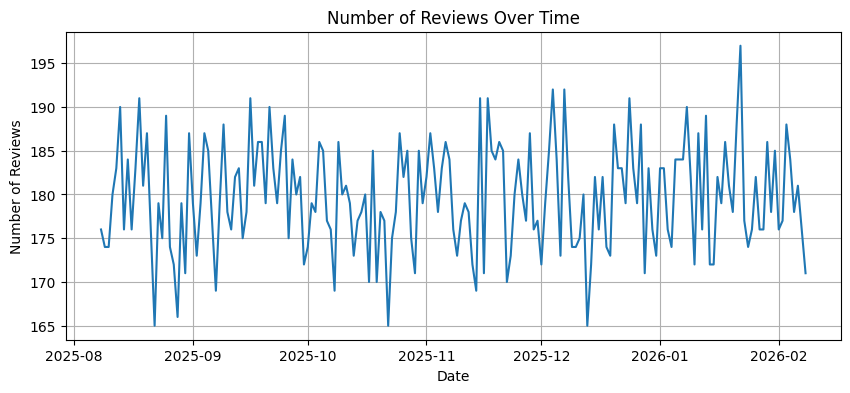

In [5]:
# Convert if not already
datetime = pd.DataFrame()
datetime['datetime'] = pd.to_datetime(df_healthcare_triple['datetime'])

# Group by date only (without time) and count tweets per day
datetime['date'] = datetime['datetime'].dt.date
review_counts = datetime.groupby('date').size()

plt.figure(figsize=(10, 4))
review_counts.plot()

plt.title('Number of Reviews Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.grid(True)
plt.show()

In [6]:
# Encode the sentiment labels into numerical format
label_encoder = LabelEncoder()
df_healthcare_triple['label_encoded'] = label_encoder.fit_transform(df_healthcare_triple['label'])
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Sentiment classes:", class_mapping)

Sentiment classes: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


In [7]:
print(df_healthcare_triple['label_encoded'].value_counts())

label_encoded
2    14435
1    11086
0     7724
Name: count, dtype: int64


In [8]:
df_healthcare_triple.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33245 entries, 0 to 33244
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   cleaned_review_text  33245 non-null  object             
 1   label                33245 non-null  object             
 2   datetime             33245 non-null  datetime64[ns, UTC]
 3   label_encoded        33245 non-null  int64              
dtypes: datetime64[ns, UTC](1), int64(1), object(2)
memory usage: 1.0+ MB


In [9]:
# Calculate the length of each 
df_healthcare_triple['text_length'] = df_healthcare_triple['cleaned_review_text'].fillna('').apply(lambda x: len(x.strip().split()))
df_healthcare_triple = df_healthcare_triple[df_healthcare_triple['text_length'] > 1]

df_healthcare_triple.head()

,cleaned_review_text,label,datetime,label_encoded,text_length
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral,2025-08-08 00:21:01+00:00,1,76
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive,2025-08-08 00:29:16+00:00,2,31
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral,2025-08-08 00:34:46+00:00,1,66
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral,2025-08-08 00:37:32+00:00,1,135
4,"I'm not sure why this is rated so badly! I love this birth control. I've had no problems with my mood and I have been on it for about a year. 2 months after taking it I stopped getting my period. I looked it up and it says that this pill does tend to make your period much lighter and shorter. I had a pretty light period to begin with so this could be the cause. Anyway, no problems with this pill at all!",Positive,2025-08-08 00:39:43+00:00,2,84


In [10]:
def detect_language(text):
    try:
        return Detector(text).language.code
    except:
        return None

languages = pd.DataFrame()      
languages['code'] = df_healthcare_triple['cleaned_review_text'].apply(detect_language)

In [11]:
language_counts = languages['code'].value_counts()
print(language_counts)

code
en    33239
es        4
de        2
Name: count, dtype: int64


# 🌐 Translate Data to English

Since the dataset contains multiple languages, we will use **Google Translate** to convert all text into **English** to ensure consistency and ease of analysis.

We'll be using the googletrans package to perform the translations.

In [12]:
async def translate_text(text):
    async with Translator() as translator:
        result = await translator.translate(text, dest='en')
        return result.text      
    
# Directly calling the async function without asyncio.run() in a Jupyter environment
await translate_text('يا الله i am hungry')

'Oh God, I am hungry'

In [13]:
# Allow asyncio to run in notebook
nest_asyncio.apply()

semaphore = asyncio.Semaphore(15)  # Limit concurrency to avoid rate limiting

async def translate_text(text, retries=3):
    async with semaphore:
        for attempt in range(retries):
            try:
                async with Translator() as translator:
                    result = await translator.translate(text, dest='en')
                    return result.text
            except Exception as e:
                await asyncio.sleep(1 + attempt * 2)  # Backoff
                if attempt == retries - 1:
                    return f"ERROR: {str(e)}"

async def translate_column(text_list):
    return await tqdm_asyncio.gather(*(translate_text(text) for text in text_list))

start = time.time()
df_healthcare_triple['translated_cleaned_review_text'] = await translate_column(df_healthcare_triple['cleaned_review_text'].tolist())
end  = time.time()
print(f"Translation completed in {(end - start)/60:.2f} minutes")

100%|██████████| 33245/33245 [34:57<00:00, 15.85it/s]  

Translation completed in 34.96 minutes


In [14]:
df_healthcare_triple.head(15)

,cleaned_review_text,label,datetime,label_encoded,text_length,translated_cleaned_review_text
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral,2025-08-08 00:21:01+00:00,1,76,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive,2025-08-08 00:29:16+00:00,2,31,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral,2025-08-08 00:34:46+00:00,1,66,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling."
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral,2025-08-08 00:37:32+00:00,1,135,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!
4,"I'm not sure why this is rated so badly! I love this birth control. I've had no problems with my mood and I have been on it for about a year. 2 months after taking it I stopped getting my period. I looked it up and it says that this pill does tend to make your period much lighter and shorter. I had a pretty light period to begin with so this could be the cause. Anyway, no problems with this pill at all!",Positive,2025-08-08 00:39:43+00:00,2,84,"I'm not sure why this is rated so badly! I love this birth control. I've had no problems with my mood and I have been on it for about a year. 2 months after taking it I stopped getting my period. I looked it up and it says that this pill doe

In [15]:
# map real, notable hospitals to each specified countries
hospital_pool = {
    "USA": ["Mayo Clinic", "Cleveland Clinic", "Johns Hopkins Hospital", "Massachusetts General Hospital"],
    "Canada": ["Toronto General Hospital", "Montreal General Hospital", "Vancouver General Hospital", "Sunnybrook Health Sciences"],
    "Australia": ["The Royal Melbourne Hospital", "Alfred Hospital", "Royal Prince Alfred Hospital", "Fiona Stanley Hospital"],
    "New Zealand": ["Auckland City Hospital", "Wellington Hospital", "Christchurch Hospital", "Middlemore Hospital"],
    "Singapore": ["Singapore General Hospital", "National University Hospital", "Tan Tock Seng Hospital", "Changi General Hospital"],
    "Israel": ["Sheba Medical Center", "Ichilov Hospital (Tel Aviv Sourasky)", "Hadassah Medical Center", "Rambam Health Care Campus"],
    "Switzerland": ["University Hospital Zurich", "Geneva University Hospitals (HUG)", "Inselspital Bern", "Basel University Hospital"],
    "Saudi Arabia": ["King Faisal Specialist Hospital", "King Fahd Medical City", "National Guard Health Affairs", "King Abdullah Medical City"],
    "India": ["All India Institute of Medical Sciences (AIIMS)", "Apollo Hospitals", "Fortis Healthcare", "Medanta The Medicity"]
}

# flatten the dictionary into a look-up list of tuples: (Hospital, Country)
flat_pool = [
    (hospital, country) 
    for country, hospitals in hospital_pool.items() 
    for hospital in hospitals
]

# use NumPy to pick random indices from pool matching the length of DataFrame
np.random.seed(42)  # ensures reproducibility across notebook cells
random_indices = np.random.choice(len(flat_pool), size=len(df_healthcare_triple), replace=True)

# extract paired hospital names and countries based on those random choices
simulated_hospitals = [flat_pool[i][0] for i in random_indices]
simulated_countries = [flat_pool[i][1] for i in random_indices]

# inject the simulated data right into DataFrame columns
df_healthcare_triple['Hospital'] = simulated_hospitals
df_healthcare_triple['Country'] = simulated_countries

# preview the freshly simulated DataFrame columns
df_healthcare_triple.head(10)

,cleaned_review_text,label,datetime,label_encoded,text_length,translated_cleaned_review_text,Hospital,Country
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral,2025-08-08 00:21:01+00:00,1,76,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,King Faisal Specialist Hospital,Saudi Arabia
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive,2025-08-08 00:29:16+00:00,2,31,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Christchurch Hospital,New Zealand
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral,2025-08-08 00:34:46+00:00,1,66,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Sunnybrook Health Sciences,Canada
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral,2025-08-08 00:37:32+00:00,1,135,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Sheba Medical Center,Israel
4,"I'm not sure why this is rated so badly! I love this birth control. I've had no problems with my mood and I have been on it for about a year. 2 months after taking it I stopped getting my period. I looked it up and it says that this pill does tend to make your period much lighter and shorter. I had a pretty light period to begin with so this could be the cause. Anyway, no problems with this pill at all!",Positive,2025-08-08 00:39:43+00:00,2,84,"I'm not sure why this is rated so badly! I love this birth control. I've had no pro

# 🧹 Data Cleaning & Preprocessing

The next step is to clean the data and prepare it for sentiment analysis. We'll perform the following tasks:

* **Expanding contractions** For example, converting "don't" to "do not", "I'm" to "I am", which helps with better tokenization and interpretation.

* **Remove unnecessary characters** (e.g., URLs, special symbols, emojis).

* **Convert text to lowercase** to maintain uniformity.

* **Remove stop words** Commonly used words such as “the”, “is”, “and” that do not add much semantic value are removed to focus on the key meaningful words.

* **Lemmatization**: Unlike stemming, lemmatization reduces words to their dictionary root form based on context and meaning (e.g., "better" → "good", "running" → "run"). It considers the context and the word’s role in a sentence. It’s more accurate because it always returns a valid word and considers the word's meaning.

> ⚙️ **Using a Preprocessing Pipeline** :
To make the preprocessing process modular, reusable, and production-ready, we encapsulate all these steps in a Scikit-learn Pipeline.The same cleaning process can be reused later (e.g., during model inference or deployment) without rewriting code. 

In [16]:
class TextPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def expand_contractions(self, text):
        return contractions.fix(text)

    def preprocess_text(self, text):
        text = self.expand_contractions(text)
        text = text.lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'@\w+|#\w+', '', text)
        text = re.sub(r'([^\w\s])', r' \1 ', text)
        text = re.sub(r'[^\w\s]', '', text)

        tokens = word_tokenize(text)
        clean_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words_en and word.isalpha()]
        return ' '.join(clean_tokens)

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        if isinstance(X, str):
            return self.preprocess_text(X)
        elif isinstance(X, pd.Series):
            return X.apply(self.preprocess_text)
        elif isinstance(X, list):
            return [self.preprocess_text(text) for text in X]
        else:
            raise TypeError("Input must be a string, list of strings, or pandas Series")

In [17]:
pipeline = Pipeline([
    ('text_preprocessor', TextPreprocessor())
])

# Apply the pipeline
df_healthcare_triple['recleaned_review_text'] = pipeline.fit_transform(df_healthcare_triple['translated_cleaned_review_text'])

In [18]:
df_healthcare_triple.head(15)

,cleaned_review_text,label,datetime,label_encoded,text_length,translated_cleaned_review_text,Hospital,Country,recleaned_review_text
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral,2025-08-08 00:21:01+00:00,1,76,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,King Faisal Specialist Hospital,Saudi Arabia,see lot bad comment birth control idea pill year love made boob whole cup size bigger gain weight also noticed mood swing barely period good recommend also cheap
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive,2025-08-08 00:29:16+00:00,2,31,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Christchurch Hospital,New Zealand,taken lost pound due surgery stopped today started hoping go wish luck
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral,2025-08-08 00:34:46+00:00,1,66,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Sunnybrook Health Sciences,Canada,book started slowly patiently waited get better read bored got realized care anything happening novel writing dull well character gene causing finny break leg stuff happened less thrilling
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral,2025-08-08 00:37:32+00:00,1,135,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Sheba Medical Center,Israel,got implanon wednesday friday afternoon happy healing process far insertion quick freaked r

# 📈 Lexicon-Based Sentiment Analysis Using VADER As Benchmark

In this step, we perform sentiment analysis on the cleaned and preprocessed tweets using **VADER (Valence Aware Dictionary and sEntiment Reasoner)** — a lexicon and rule-based sentiment analysis tool specifically designed for social media text. We use VADER to classify tweets into four sentiment categories: very negative, negative, positive, and very positive.

**Why VADER?**

* Designed specifically for sentiments expressed in social media contexts such as tweets.

* Handles emojis, slang, negations, and intensity modifiers.

* Provides a compound score that captures overall sentiment polarity ranging from -1 (most negative) to +1 (most positive).

* Outputs fine-grained sentiment scores: positive, negative, neutral, and compound.

In [19]:
# Initialize the VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Function to classify sentiment
def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    sentiment_label = ''
    if score >= 0.7:
        sentiment_label = 'very positive'
    elif score > 0:
        sentiment_label = 'positive'
    elif score <= -0.7:
        sentiment_label = 'very negative'
    else:
        sentiment_label = 'negative'
    return score, sentiment_label

# Apply sentiment analysis to the cleaned text
df_healthcare_triple[['sentiment_score', 'sentiment_label']] = df_healthcare_triple['cleaned_review_text'].apply(get_sentiment).apply(pd.Series)

In [20]:
df_healthcare_triple.head(15)

,cleaned_review_text,label,datetime,label_encoded,text_length,translated_cleaned_review_text,Hospital,Country,recleaned_review_text,sentiment_score,sentiment_label
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral,2025-08-08 00:21:01+00:00,1,76,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,King Faisal Specialist Hospital,Saudi Arabia,see lot bad comment birth control idea pill year love made boob whole cup size bigger gain weight also noticed mood swing barely period good recommend also cheap,0.1232,positive
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive,2025-08-08 00:29:16+00:00,2,31,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Christchurch Hospital,New Zealand,taken lost pound due surgery stopped today started hoping go wish luck,0.6486,positive
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral,2025-08-08 00:34:46+00:00,1,66,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Sunnybrook Health Sciences,Canada,book started slowly patiently waited get better read bored got realized care anything happening novel writing dull well character gene causing finny break leg stuff happened less thrilling,0.0518,positive
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral,2025-08-08 00:37:32+00:00,1,135,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Sheba Medical Center,Israel,got implano

/tmp/ipykernel_106/1517600506.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)


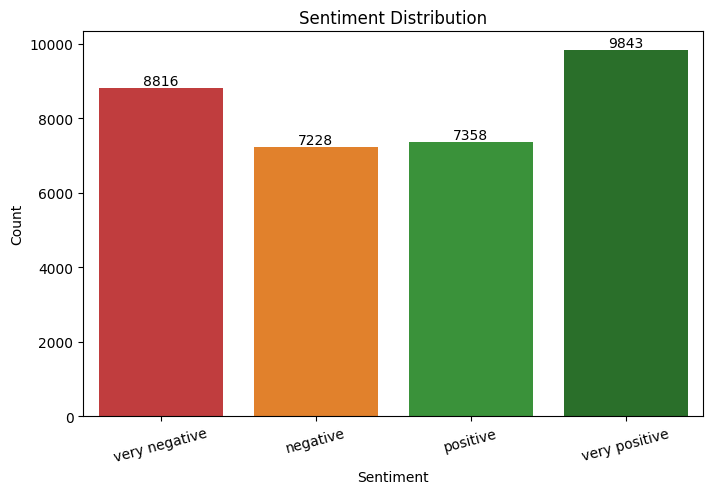

In [21]:
# Define the order and colors for sentiment labels
sentiment_order = ['very negative', 'negative', 'positive', 'very positive']
colors = ['#D62728', '#FF7F0E', '#2CA02C', '#1F7A1F']  # red, orange, green, dark green

# Count sentiment occurrences in your dataset
sentiment_counts = df_healthcare_triple['sentiment_label'].value_counts().reindex(sentiment_order, fill_value=0)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=15)

# Add subtitles for each label count
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
    
plt.show()

/tmp/ipykernel_106/2703040620.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)


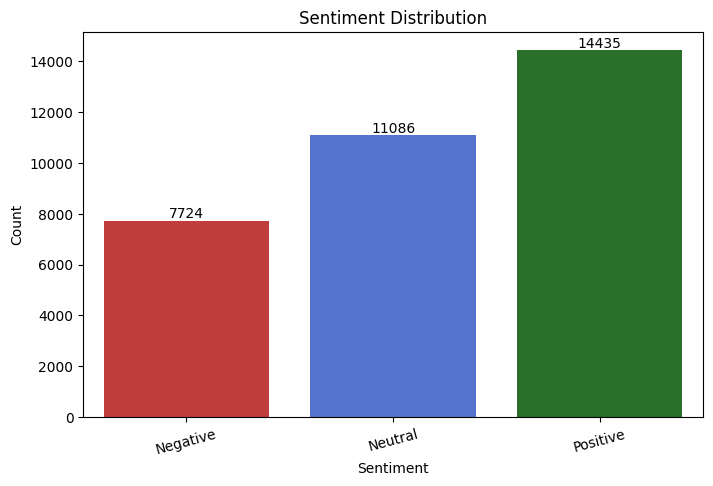

In [22]:
# Define the order and colors for sentiment labels
sentiment_order = ['Negative', 'Neutral', 'Positive']
colors = ['#D62728', '#4169E1', '#1F7A1F']  # red, blue, dark green

# Count sentiment occurrences in your dataset
sentiment_counts = df_healthcare_triple['label'].value_counts().reindex(sentiment_order, fill_value=0)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=15)

# Add subtitles for each label count
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
    
plt.show()

In [23]:
df_healthcare_triple['label_clean'] = df_healthcare_triple['label'].astype(str).str.strip().str.lower()
df_healthcare_triple['sentiment_label_clean'] = df_healthcare_triple['sentiment_label'].astype(str).str.strip().str.lower()

negative_targets = ['negative', 'very negative']
positive_targets = ['positive', 'very positive']

# -------------------------------------------------------------------------
# RULE 1: label_2_clean is positive/very positive BUT label_1_clean is negative
# Action: Force label_2_clean to 'negative'
# -------------------------------------------------------------------------
condition_to_negative = (
    df_healthcare_triple['sentiment_label_clean'].isin(['very positive']) & 
    (df_healthcare_triple['label_clean'] == 'negative')
)

# -------------------------------------------------------------------------
# RULE 2: label_2_clean is negative/very negative/typo BUT label_1_clean is positive
# Action: Force label_2_clean to 'positive'
# -------------------------------------------------------------------------
condition_to_positive = (
    df_healthcare_triple['sentiment_label_clean'].isin(['very negative']) & 
    (df_healthcare_triple['label_clean'] == 'positive')
)

# 2. Count modifications before applying changes (for auditing)
changed_to_neg = condition_to_negative.sum()
changed_to_pos = condition_to_positive.sum()

# 3. Apply updates to 'label_2_clean'
df_healthcare_triple.loc[condition_to_negative, 'sentiment_label_clean'] = 'negative'
df_healthcare_triple.loc[condition_to_positive, 'sentiment_label_clean'] = 'positive'

# 5. Print out confirmation metrics
print("🛠️ --- DATA SYNCHRONIZATION SUMMARY ---")
print(f"Rows forced to 'negative' (were positive/very positive conflict): {changed_to_neg:,}")
print(f"Rows forced no 'positive' (were negative/very negative conflict): {changed_to_pos:,}")
print(f"Total polar corrections executed: {changed_to_neg + changed_to_pos:,}")
print("---------------------------------------\n")

# Review a small sample of your table
df_healthcare_triple.head()

🛠️ --- DATA SYNCHRONIZATION SUMMARY ---
Rows forced to 'negative' (were positive/very positive conflict): 837
Rows forced no 'positive' (were negative/very negative conflict): 2,693
Total polar corrections executed: 3,530
---------------------------------------



,cleaned_review_text,label,datetime,label_encoded,text_length,translated_cleaned_review_text,Hospital,Country,recleaned_review_text,sentiment_score,sentiment_label,label_clean,sentiment_label_clean
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral,2025-08-08 00:21:01+00:00,1,76,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,King Faisal Specialist Hospital,Saudi Arabia,see lot bad comment birth control idea pill year love made boob whole cup size bigger gain weight also noticed mood swing barely period good recommend also cheap,0.1232,positive,neutral,positive
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive,2025-08-08 00:29:16+00:00,2,31,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Christchurch Hospital,New Zealand,taken lost pound due surgery stopped today started hoping go wish luck,0.6486,positive,positive,positive
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral,2025-08-08 00:34:46+00:00,1,66,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Sunnybrook Health Sciences,Canada,book started slowly patiently waited get better read bored got realized care anything happening novel writing dull well character gene causing finny break leg stuff happened less thrilling,0.0518,positive,neutral,positive
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral,2025-08-08 00:37:32+00:00,1,135,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advise

/tmp/ipykernel_106/946177042.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)


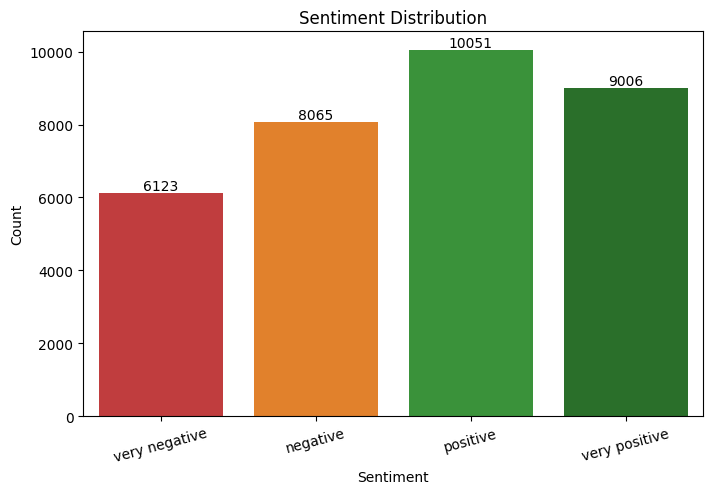

In [24]:
# Define the order and colors for sentiment labels
sentiment_order = ['very negative', 'negative', 'positive', 'very positive']
colors = ['#D62728', '#FF7F0E', '#2CA02C', '#1F7A1F']  # red, orange, green, dark green

# Count sentiment occurrences in your dataset
sentiment_counts = df_healthcare_triple['sentiment_label_clean'].value_counts().reindex(sentiment_order, fill_value=0)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette=colors)

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=15)

# Add subtitles for each label count
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')
    
plt.show()

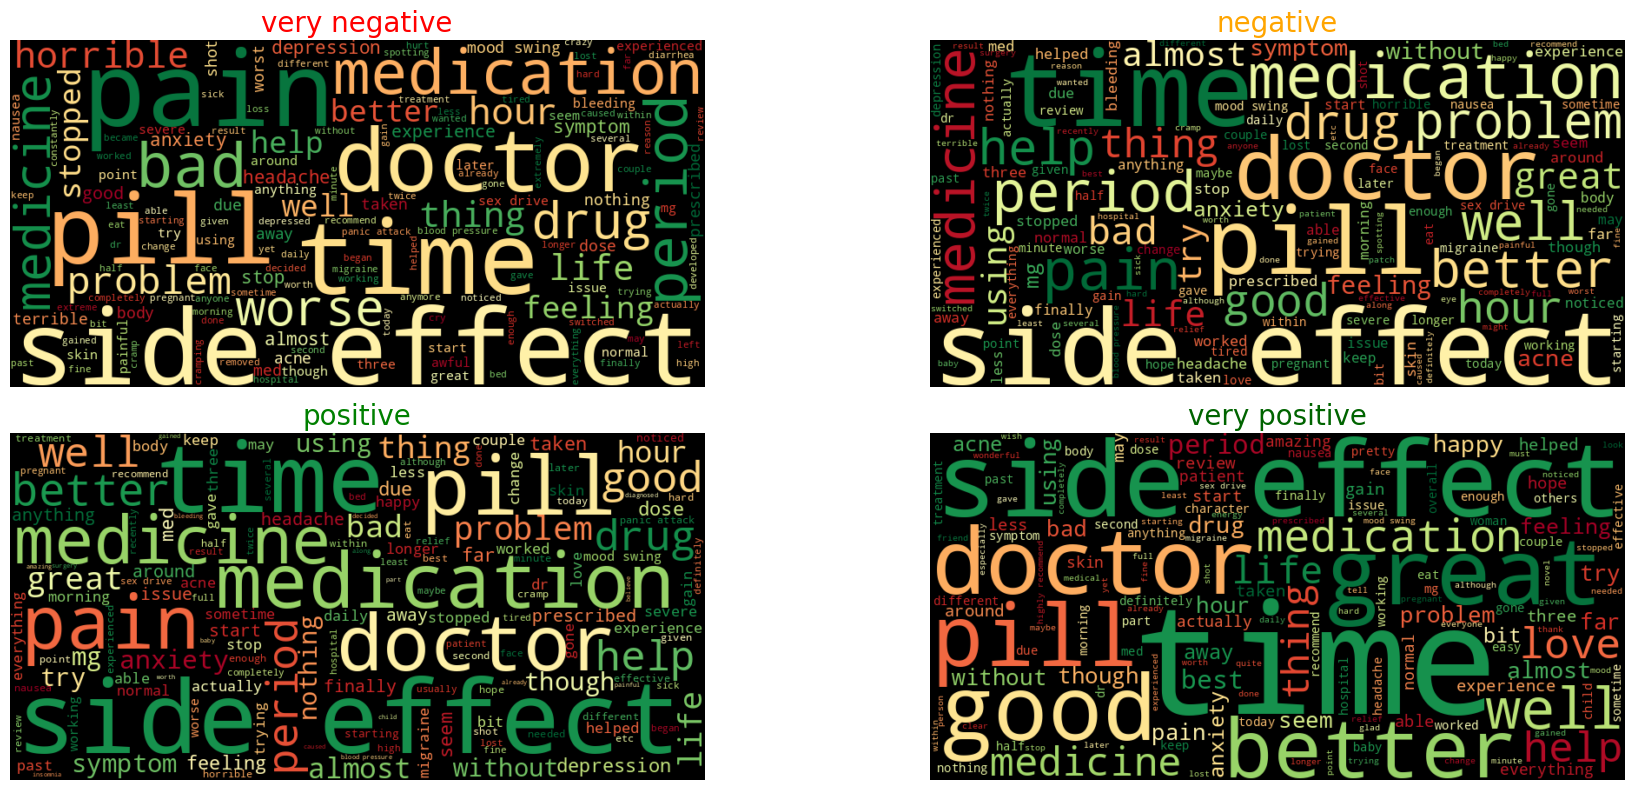

In [25]:
# Sentiment categories in order
sentiment_order = ['very negative', 'negative', 'positive', 'very positive']

# Define color mapping for sentiment labels
label_colors = {
    'very negative': 'red',
    'negative': 'orange',
    'positive': 'green',
    'very positive': 'darkgreen'
}

plt.figure(figsize=(20, 8))

# 1. Define a basic list of English stop words to ignore
stop_words = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", 
    'your', 'yours', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 
    'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 
    'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 
    'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 
    'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 
    'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 
    'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 
    'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 
    'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 
    's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 
    'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', 
    "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', 
    "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't",
    'would', 'could', 'get', 'go', 'one', 'place', 'he', 'she', 'back', 'even', 
    'us', 'told', 'said', 'never', 'really', 'food', 'got', 'went', 'going', 'see',
    'first', 'also', 'know', 'nni', 'called', 'make', 'asked', 'came', 'people',
    'day', 'minutes', 'another', 'take', 'took', 'call', 'made', 'new', 'two', 
    'much', 'way', 'come', 'right', 'since', 'always', 'still', 'give', 'ever',
    'need', 'say', 'nnthe', 'little', 'years', 'want', 'waiting', 'visit', 'work',
    'think', 'order', 'office', 'sure', 'room', 'feel', 'next', 'movie',
    'book', 'books', 'read', 'reading', 'story', 'many', 'found', 'find', 'use', 
    'film', 'author', 'characters', 'however', 'old', 'product', 'lot', 'written',
    'bought', 'thought', 'every', 'used', 'end', 'something', 'put', 'long',
    'taking', 'months', 'started', 'days', 'weeks', 'week', 'month', 'felt',
    'control', 'year', 'night', 'ago', 'weight', 'tried', 'birth', 'sleep',
    'last', 'hours', 'getting'# Custom dataset context words
])

for i, sentiment in enumerate(sentiment_order, 1):
    # Join all cleaned texts belonging to this sentiment
    text_corpus = df_healthcare_triple.loc[df_healthcare_triple['sentiment_label_clean'] == sentiment, 'recleaned_review_text'].fillna("").astype(str)
    all_words = []

    for text in text_corpus:
        # Use regex to isolate words, stripping out punctuation
        words = re.findall(r'\b[a-z]{2,}\b', text.lower()) 
        # Append words that are NOT in our stop_words list
        all_words.extend([word for word in words if word not in stop_words])
    
    # Generate word cloud
    wc = WordCloud(
        width=800, 
        height=400, 
        background_color='black',  # Black contrasts best with RdYlGn hues
        colormap='RdYlGn_r',         # Red-Yellow-Green gradient map (less frequent, darker red --> more frequent, darker green)
        max_words=150, 
        random_state=42).generate(" ".join(all_words))

    # Plot subplot
    plt.subplot(2, 2, i)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(sentiment, fontsize=20, color=label_colors[sentiment])
    plt.axis('off')

plt.tight_layout()
plt.show()

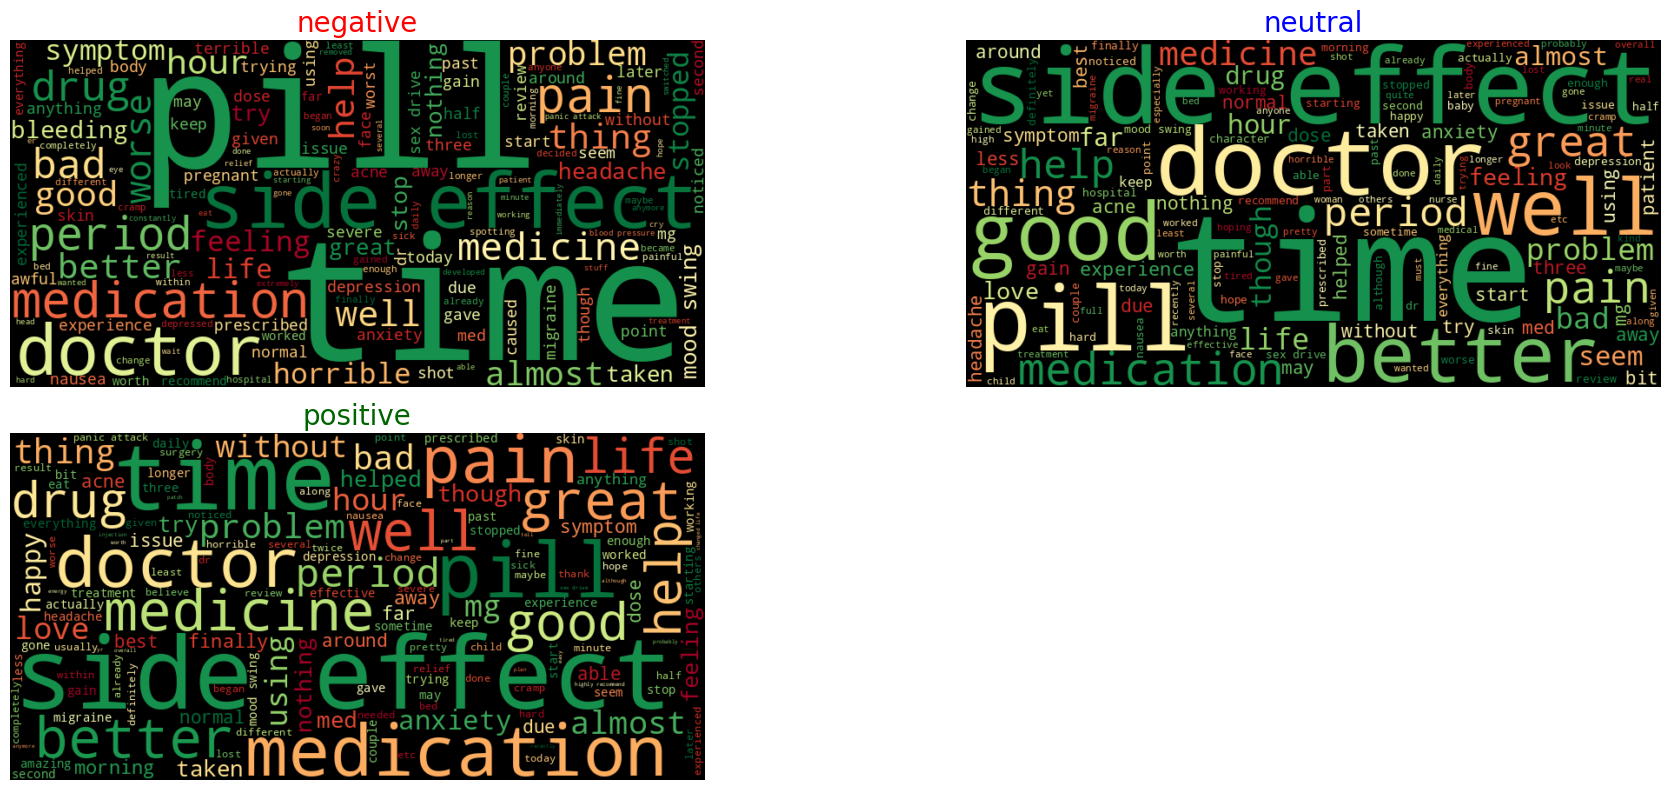

In [26]:
# Sentiment categories in order
sentiment_order = ['negative', 'neutral', 'positive']

# Define color mapping for sentiment labels
label_colors = {
    'negative': 'red',
    'neutral': 'blue',
    'positive': 'darkgreen'
}

plt.figure(figsize=(20, 8))

# 1. Define a basic list of English stop words to ignore
stop_words = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", 
    'your', 'yours', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 
    'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 
    'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 
    'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 
    'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 
    'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 
    'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 
    'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 
    'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 
    'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 
    'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 
    's', 't', 'can', 'will', 'just', 'don', "don't", 'should', "should've", 'now', 
    'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn', 
    "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', 
    "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 
    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't",
    'would', 'could', 'get', 'go', 'one', 'place', 'he', 'she', 'back', 'even', 
    'us', 'told', 'said', 'never', 'really', 'food', 'got', 'went', 'going', 'see',
    'first', 'also', 'know', 'nni', 'called', 'make', 'asked', 'came', 'people',
    'day', 'minutes', 'another', 'take', 'took', 'call', 'made', 'new', 'two', 
    'much', 'way', 'come', 'right', 'since', 'always', 'still', 'give', 'ever',
    'need', 'say', 'nnthe', 'little', 'years', 'want', 'waiting', 'visit', 'work',
    'think', 'order', 'office', 'sure', 'room', 'feel', 'next', 'movie',
    'book', 'books', 'read', 'reading', 'story', 'many', 'found', 'find', 'use', 
    'film', 'author', 'characters', 'however', 'old', 'product', 'lot', 'written',
    'bought', 'thought', 'every', 'used', 'end', 'something', 'put', 'long',
    'taking', 'months', 'started', 'days', 'weeks', 'week', 'month', 'felt',
    'control', 'year', 'night', 'ago', 'weight', 'tried', 'birth', 'sleep',
    'last', 'hours', 'getting'# Custom dataset context words
])

for i, sentiment in enumerate(sentiment_order, 1):
    # Join all cleaned texts belonging to this sentiment
    text_corpus = df_healthcare_triple.loc[df_healthcare_triple['label_clean'] == sentiment, 'recleaned_review_text'].fillna("").astype(str)
    all_words = []

    for text in text_corpus:
        # Use regex to isolate words, stripping out punctuation
        words = re.findall(r'\b[a-z]{2,}\b', text.lower()) 
        # Append words that are NOT in our stop_words list
        all_words.extend([word for word in words if word not in stop_words])
    
    # Generate word cloud
    wc = WordCloud(
        width=800, 
        height=400, 
        background_color='black',  # Black contrasts best with RdYlGn hues
        colormap='RdYlGn_r',         # Your Red-Yellow-Green gradient map
        max_words=150, 
        random_state=42).generate(" ".join(all_words))

    # Plot subplot
    plt.subplot(2, 2, i)
    plt.imshow(wc, interpolation='bilinear')
    plt.title(sentiment, fontsize=20, color=label_colors[sentiment])
    plt.axis('off')

plt.tight_layout()
plt.show()

# 🔥 Risk Detection Based on Sentiment

In this step, we assess potential risk levels by leveraging the sentiment scores generated using VADER. The idea is that highly negative sentiment may indicate higher concern or distress related to food security. We assign risk levels based on the compound sentiment score:

* High Risk: Strongly negative sentiment (score ≤ -0.6)

* Medium Risk: Mildly negative to neutral sentiment (score between -0.6 and 0)

* Low Risk: Positive sentiment (score > 0)

This risk scoring helps to identify regions or users expressing greater concern, enabling targeted analysis of food security threats across different areas.

In [27]:
# -------------------------------------------------------------------------
# RULE 1
# -------------------------------------------------------------------------
condition_to_high = (
    df_healthcare_triple['sentiment_label_clean'].isin(['very negative', 'negative', 'positive']) & 
    (df_healthcare_triple['label_clean'] == 'negative')
)

# -------------------------------------------------------------------------
# RULE 2
# -------------------------------------------------------------------------
condition_to_med = (
    df_healthcare_triple['sentiment_label_clean'].isin(['very negative', 'negative', 'positive', 'very positive']) & 
    (df_healthcare_triple['label_clean'] == 'neutral')
)

# -------------------------------------------------------------------------
# RULE 3
# -------------------------------------------------------------------------
condition_to_low = (
    df_healthcare_triple['sentiment_label_clean'].isin(['negative', 'positive', 'very positive']) & 
    (df_healthcare_triple['label_clean'] == 'positive')
)

# 2. Count modifications before applying changes (for auditing)
changed_to_high = condition_to_high.sum()
changed_to_med = condition_to_med.sum()
changed_to_low = condition_to_low.sum()

# 3. Apply updates to 'label_2_clean'
df_healthcare_triple.loc[condition_to_high, 'risk_label'] = 'High'
df_healthcare_triple.loc[condition_to_med, 'risk_label'] = 'Medium'
df_healthcare_triple.loc[condition_to_low, 'risk_label'] = 'Low'

# 5. Print out confirmation metrics
print("🛠️ --- DATA SYNCHRONIZATION SUMMARY ---")
print(f"Rows Risk 'High': {changed_to_high:,}")
print(f"Rows Risk 'Medium': {changed_to_med:,}")
print(f"Rows Risk 'Low': {changed_to_low:,}")
print(f"Total risks: {changed_to_high + changed_to_med + changed_to_low:,}")
print("---------------------------------------\n")

# Review a small sample of your table
df_healthcare_triple.head()

🛠️ --- DATA SYNCHRONIZATION SUMMARY ---
Rows Risk 'High': 7,724
Rows Risk 'Medium': 11,086
Rows Risk 'Low': 14,435
Total risks: 33,245
---------------------------------------



,cleaned_review_text,label,datetime,label_encoded,text_length,translated_cleaned_review_text,Hospital,Country,recleaned_review_text,sentiment_score,sentiment_label,label_clean,sentiment_label_clean,risk_label
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral,2025-08-08 00:21:01+00:00,1,76,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,King Faisal Specialist Hospital,Saudi Arabia,see lot bad comment birth control idea pill year love made boob whole cup size bigger gain weight also noticed mood swing barely period good recommend also cheap,0.1232,positive,neutral,positive,Medium
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive,2025-08-08 00:29:16+00:00,2,31,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Christchurch Hospital,New Zealand,taken lost pound due surgery stopped today started hoping go wish luck,0.6486,positive,positive,positive,Low
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral,2025-08-08 00:34:46+00:00,1,66,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Sunnybrook Health Sciences,Canada,book started slowly patiently waited get better read bored got realized care anything happening novel writing dull well character gene causing finny break leg stuff happened less thrilling,0.0518,positive,neutral,positive,Medium
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral,2025-08-08 00:37:32+00:00,1,135,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next W

In [28]:
df_healthcare_triple.head(15)

,cleaned_review_text,label,datetime,label_encoded,text_length,translated_cleaned_review_text,Hospital,Country,recleaned_review_text,sentiment_score,sentiment_label,label_clean,sentiment_label_clean,risk_label
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral,2025-08-08 00:21:01+00:00,1,76,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,King Faisal Specialist Hospital,Saudi Arabia,see lot bad comment birth control idea pill year love made boob whole cup size bigger gain weight also noticed mood swing barely period good recommend also cheap,0.1232,positive,neutral,positive,Medium
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive,2025-08-08 00:29:16+00:00,2,31,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Christchurch Hospital,New Zealand,taken lost pound due surgery stopped today started hoping go wish luck,0.6486,positive,positive,positive,Low
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral,2025-08-08 00:34:46+00:00,1,66,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Sunnybrook Health Sciences,Canada,book started slowly patiently waited get better read bored got realized care anything happening novel writing dull well character gene causing finny break leg stuff happened less thrilling,0.0518,positive,neutral,positive,Medium
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral,2025-08-08 00:37:32+00:00,1,135,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next W

/tmp/ipykernel_106/2156396114.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_healthcare_triple, x='risk_label', order=risk_order, palette=risk_colors)


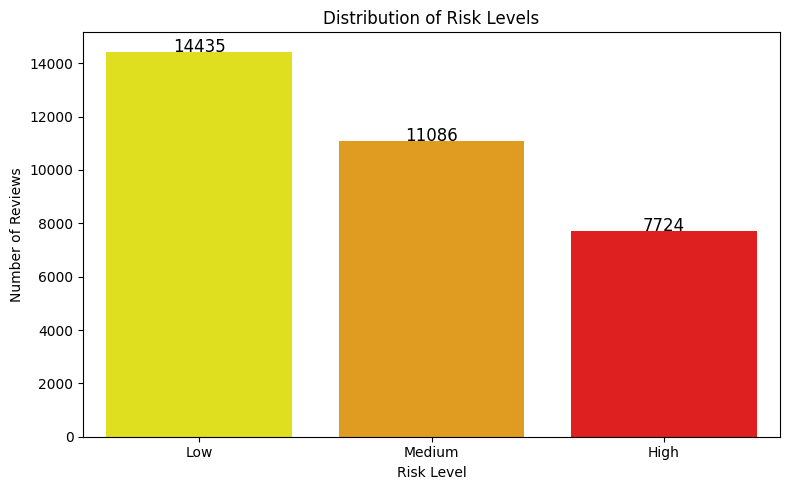

In [29]:
# Define the order and colors for risk levels
risk_order = ['Low', 'Medium', 'High']
risk_colors = ['yellow', 'orange', 'red']

plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_healthcare_triple, x='risk_label', order=risk_order, palette=risk_colors)

# Add count numbers on top of the bars
for p in ax.patches:
    count = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2., p.get_height() + 3,
            str(count), ha='center', fontsize=12)

plt.title('Distribution of Risk Levels')
plt.xlabel('Risk Level')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

# 📝 Topic Modelling for Patient Reported Experience Measures (PREMs) Using LDA

In this step, we applied **Latent Dirichlet Allocation (LDA)** to identify latent themes related to food insecurity in the tweet dataset. **LDA** is an **unsupervised topic modeling technique** that groups frequently co-occurring words into coherent topics. To determine the optimal number of topics, we trained multiple LDA models with **varying topic counts (from 2 to 10)**, evaluating each using **perplexity** and **coherence scores**. This approach helps balance both statistical fit and semantic interpretability.

Each review was then assigned to the most probable topic to enable further analysis.

In [30]:
# Prepare the corpus
docs = df_healthcare_triple['recleaned_review_text'].dropna().tolist()

# Vectorize text into a document-term matrix
vectorizer = CountVectorizer(min_df=2, stop_words='english')
dtm = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

In [31]:
# Conversion for Gensim (Coherence)
tokenized_docs = [doc.split() for doc in docs]
dictionary = Dictionary(tokenized_docs)
corpus_gensim = [dictionary.doc2bow(text) for text in tokenized_docs]

In [ ]:
# Range of topics to test
#topic_range = range(2, 31) #from 2 to 30 topics

# Storage of results
#perplexities = []
#coherences = []

#for n_topics in topic_range:
#    lda_model = LatentDirichletAllocation(n_components=n_topics,
#                                          max_iter=15,
#                                          learning_method='batch',
#                                          random_state=0)
#    lda_model.fit(dtm)

    # Perplexity
#    perplexity = lda_model.perplexity(dtm)
#    perplexities.append(perplexity)

    # Coherence (gensim)
#    topics = []
#    for topic_idx, topic in enumerate(lda_model.components_):
#        top_indices = topic.argsort()[-10:][::-1]
#        top_words = [feature_names[i] for i in top_indices]
#        topics.append(top_words)
    
#    coherence_model = CoherenceModel(topics=topics,
#                                     texts=tokenized_docs,
#                                     dictionary=dictionary,
#                                     coherence='c_v')
#    coherence_score = coherence_model.get_coherence()
#    coherences.append(coherence_score)

#    print(f"Topics: {n_topics} | Perplexity: {perplexity:.2f} | Coherence: {coherence_score:.4f}")

In [ ]:
# Find the best number of topics
#best_n_topics_perplexity = topic_range[np.argmin(perplexities)]
#best_n_topics_coherence = topic_range[np.argmax(coherences)]

#print(f"Best number of topics based on Perplexity: {best_n_topics_perplexity}")
#print(f"Best number of topics based on Coherence Score: {best_n_topics_coherence}")

To pick the absolute best number of topics for your healthcare dataset, it helps to understand exactly what these two metrics are calculating under the hood.

Think of **Perplexity** as the metric for the AI/Computer, and **Coherence** as the metric for the Human.

## 📉 1. Perplexity (The Computer's Metric)
* What it means mathematically: Perplexity is a measure of how "surprised" or confused a statistical language model is when it encounters new text. It is calculated as the inverse geometric mean of the likelihood of the words in your dataset.

* In plain English: It tests the model's predictive power. If you split a patient's review in half, can the model successfully guess the remaining words based on the topics it has learned?

* Why lower is better: A lower perplexity score means the model is highly confident and rarely surprised by the text layout.

* The Catch: Perplexity will almost always keep going down as you add more topics. If you tell the model to find 100 topics, its perplexity will look amazing because it basically memorized every specific edge case. However, 100 topics are impossible for a human being to interpret. This is why you must look for the "Elbow"—the point where adding more topics gives you diminishing returns.

# 📈 2. Coherence (The Human's Metric)
* What it means mathematically: Coherence measures the degree of semantic similarity between high-scoring words within a single topic. The standard c_v metric uses a sliding window to check how often the top words in a topic actually appear near each other across your entire dataset (co-occurrence).

* In plain English: It measures whether the words grouped into a topic actually make sense together, or if they are just a random salad of medical vocabulary.

* Why higher is better: High coherence means the words inside a topic are tightly bound by a single unified theme.

    * High Coherence Example: [doctor, nurse, physician, staff, friendly] $\rightarrow$ Clear theme: Staff Professionalism.

    * Low Coherence Example: [hospital, billing, Tylenol, waiting, knee, rude] $\rightarrow$ Confusing theme: It mixes administrative complaints, specific symptoms, and medications into a messy cluster.
 
# 🎯 How to Find the "Sweet Spot"
When you look at your side-by-side plots, you are trying to balance a statistical tug-of-war. Here is exactly how to choose your final topic count ($K$):

COHERENCE (Higher = Better)            PERPLEXITY (Lower = Better)
          
          ^          Peak                      ^
          |           / \                      | \
          |          /   \                     |  \  Elbow
          |         /     \                    |   \_______ Flattening out
          |________/       \_______            |           \___________
          +------------------------>           +------------------------>
                    K = 6                                 K = 6

* Step 1: Isolate the Coherence PeaksLook at your Coherence graph first. Find the top 1 or 2 highest peaks (for example, say you have a sharp peak at $K = 6$ and a smaller one at $K = 10$).

* Step 2: Cross-Reference with the Perplexity CurveLook at those same numbers on your Perplexity graph. You want to make sure that at your chosen peak ($K = 6$), the perplexity curve has already gone through its steep drop and is starting to flatten out.

* Step 3: Tie-Breaker Rule (Parsimony)If $K = 6$ and $K = 10$ have nearly identical scores, always choose the lower number ($K = 6$). In text modeling, fewer topics mean broader, cleaner, and more actionable insights for your data reports!

In [ ]:
# Display of curves
#plt.figure(figsize=(12,6))
#plt.plot(topic_range, perplexities, label='Perplexity', marker='o')
#plt.ylabel('Perplexity')
#plt.xlabel('Number of Topics')
#plt.legend(loc='upper left')
#plt.twinx()
#plt.plot(topic_range, coherences, label='Coherence', color='orange', marker='s')
#plt.ylabel('Coherence Score (c_v)')
#plt.title("Model Evaluation: Perplexity vs Coherence")
#plt.legend(loc='upper right')
#plt.grid(True)
#plt.show()

After evaluating both `Perplexity` and `Coherence` Score, we found that:

* 13 topics give the lowest perplexity (better generalization)

* 27 topics give the highest coherence (better interpretability)

However, `20` topics offer a balanced trade-off between coherence and perplexity, making it a solid and interpretable choice for this dataset.

| Category | Example words/phrases it would catch |
| :--- | :--- |
| **Clinical Staff** | doctor, nurse, GP, specialist, physiotherapist, psychologist, midwife |
| **Administrative Staff** | reception, booking, billing, front desk |
| **Efficiency and Flow** | waiting, waited, queue, delay, on time, late |
| **Booking & Access** | book, appointment, portal, online, Zedoc, couldn't access |
| **Information & Shared Decision-Making** | explained, told, informed, listened, dismissed, didn't listen |
| **Dignity & Respect** | explained, told, informed, listened, dismissed, didn't listen |
| **Care Quality** | thorough, careful, rushed, excellent, poor, skilled |
| **Care Coordination** | handover, referral, transferred, GP, coordinated |
| **Results & Information** | results, report, pathology, test, didn't understand |
| **Facilities & Environment & Environmental Hygiene** | parking, car park, clean, comfortable, building |
| **Telehealth** | telehealth, video, online consult, remote, phone |
| **Emotional Support** | anxious, reassured, felt safe, valued, dismissed |
| **Cultural & Accessibility Needs** | cultural, language, disability, female practitioner |
| **Discharge & Follow-up** | discharge, follow-up, home, after care, instructions |
| **Feeling in Good Hands** | |

In [32]:
# Fit LDA
n_topics = 15
lda = LatentDirichletAllocation(n_components=n_topics,
                                max_iter=20,
                                learning_method='batch',
                                random_state=0)
lda.fit(dtm)

LatentDirichletAllocation(max_iter=20, n_components=15, random_state=0)

In [33]:
# Display the top words per topic
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        print(f"🔹 Topic #{topic_idx+1}: " + ", ".join(top_words)+"\n")

feature_names = vectorizer.get_feature_names_out()
print_top_words(lda, feature_names, n_top_words=25)

🔹 Topic #1: day, took, week, pill, period, got, time, hour, like, cramp, review, went, felt, work, insertion, pain, bad, started, later, feel, year, really, month, sex, cramping

🔹 Topic #2: period, month, pill, control, birth, year, weight, week, bleeding, mood, day, time, got, sex, effect, started, taking, swing, gain, acne, like, cramp, spotting, bad, drive

🔹 Topic #3: movie, doctor, story, like, character, film, love, good, time, really, people, end, great, series, life, make, man, scene, think, play, way, hospital, star, plot, little

🔹 Topic #4: year, month, patch, effect, use, eye, day, burning, itching, medication, using, used, treatment, symptom, week, time, taking, hair, foot, started, cancer, reaction, doctor, product, allergy

🔹 Topic #5: pain, day, year, work, taking, medicine, doctor, time, help, relief, mg, medication, effect, hour, prescribed, drug, surgery, severe, life, chronic, muscle, tried, daily, nerve, fibromyalgia

🔹 Topic #6: skin, acne, face, month, week, day

In [34]:
# Get topic distributions for each document (tweet)
topic_distributions = lda.transform(dtm)

# Assign each tweet to the topic with the highest probability
assigned_topics = np.argmax(topic_distributions, axis=1)

topic_names = {
    0: "Clinical Staff",
    1: "Administrative Staff",
    2: "Efficiency and Flow",
    3: "Booking & Access",
    4: "Information & Shared Decision-Making",
    5: "Dignity & Respect",
    6: "Care Quality",
    7: "Care Coordination",
    8: "Results & Information",
    9: "Facilities & Environment & Environmental Hygiene",
    10: "Telehealth",
    11: "Emotional Support",
    12: "Cultural & Accessibility Needs",
    13: "Discharge & Follow-up",
    14: "Feeling in Good Hands"
}

In [35]:
# Create a new column in your DataFrame for assigned topic
df_healthcare_triple['assigned_topic'] = [topic_names[i] for i in assigned_topics]

In [36]:
# Count tweets per topic
topic_counts = df_healthcare_triple['assigned_topic'].value_counts()
print("Number of tweets per topic:")
print(topic_counts)

Number of tweets per topic:
assigned_topic
Care Coordination                                   7122
Administrative Staff                                5356
Care Quality                                        2956
Results & Information                               2631
Cultural & Accessibility Needs                      2514
Information & Shared Decision-Making                2202
Clinical Staff                                      2051
Dignity & Respect                                   1608
Booking & Access                                    1457
Efficiency and Flow                                 1421
Telehealth                                          1416
Emotional Support                                   1024
Facilities & Environment & Environmental Hygiene     809
Feeling in Good Hands                                378
Discharge & Follow-up                                300
Name: count, dtype: int64


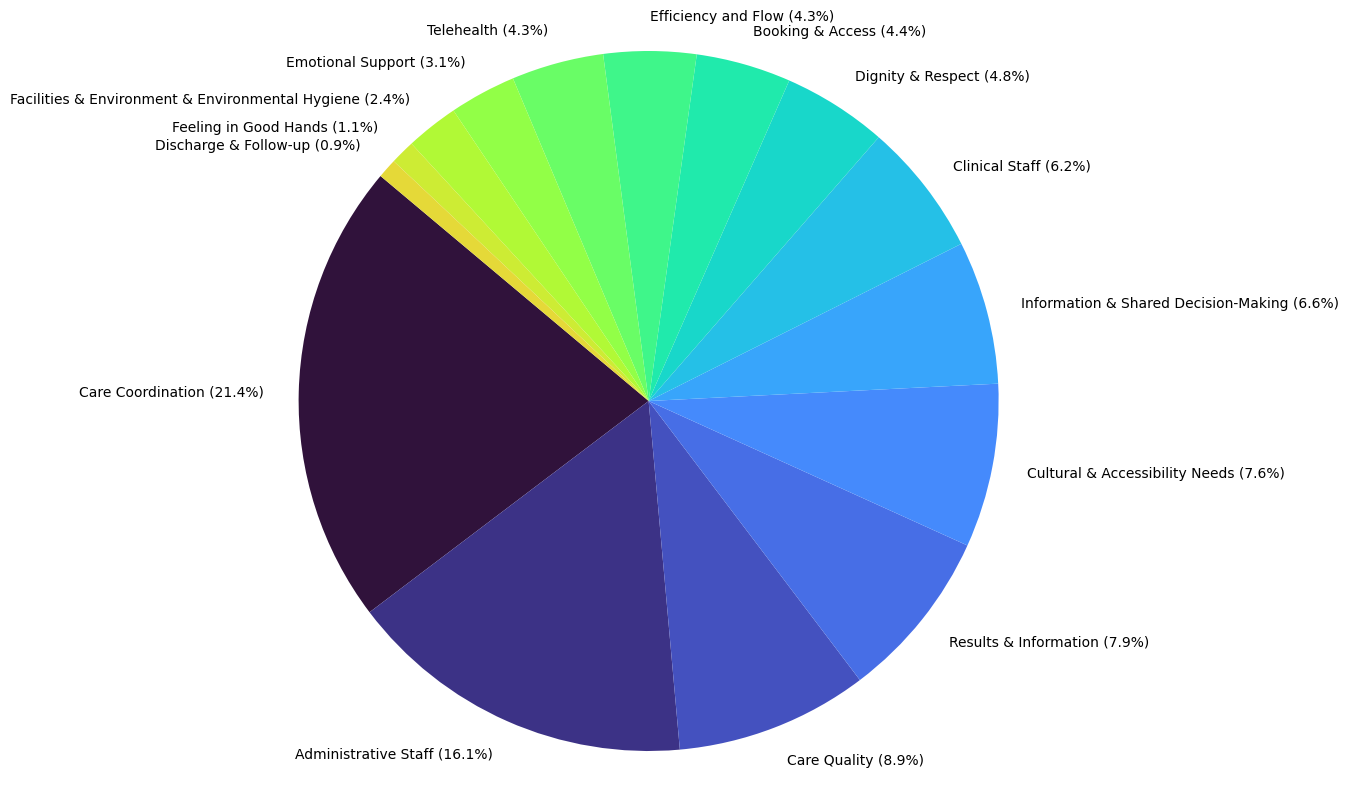

In [37]:
plt.figure(figsize=(12, 10))

# 1. Calculate percentages and attach them directly next to text labels
total_reviews = topic_counts.sum()
combined_labels = [
    f"{label} ({count / total_reviews * 100:.1f}%)" 
    for label, count in zip(topic_counts.index, topic_counts)
]

# Generate 24 distinct colors using the turbo color map
colors_24 = plt.cm.turbo(np.linspace(0, 1, 24))

# 2. Plot the pie chart passing new combined labels 
plt.pie(
    topic_counts, 
    labels=combined_labels, 
    startangle=140, 
    colors=colors_24   # <-- Updated colors list here
)

plt.axis('equal')
plt.show()

In [38]:
df_healthcare_triple.head()

,cleaned_review_text,label,datetime,label_encoded,text_length,translated_cleaned_review_text,Hospital,Country,recleaned_review_text,sentiment_score,sentiment_label,label_clean,sentiment_label_clean,risk_label,assigned_topic
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral,2025-08-08 00:21:01+00:00,1,76,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,King Faisal Specialist Hospital,Saudi Arabia,see lot bad comment birth control idea pill year love made boob whole cup size bigger gain weight also noticed mood swing barely period good recommend also cheap,0.1232,positive,neutral,positive,Medium,Administrative Staff
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive,2025-08-08 00:29:16+00:00,2,31,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Christchurch Hospital,New Zealand,taken lost pound due surgery stopped today started hoping go wish luck,0.6486,positive,positive,positive,Low,Cultural & Accessibility Needs
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral,2025-08-08 00:34:46+00:00,1,66,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Sunnybrook Health Sciences,Canada,book started slowly patiently waited get better read bored got realized care anything happening novel writing dull well character gene causing finny break leg stuff happened less thrilling,0.0518,positive,neutral,positive,Medium,Care Quality
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral,2025-08-08 00:37:32+00:00,1,135,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can noti

/tmp/ipykernel_106/1889901364.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_topic_counts = df_healthcare_triple.groupby([df_healthcare_triple['datetime'].dt.to_period('M'), 'assigned_topic']).size().unstack(fill_value=0)


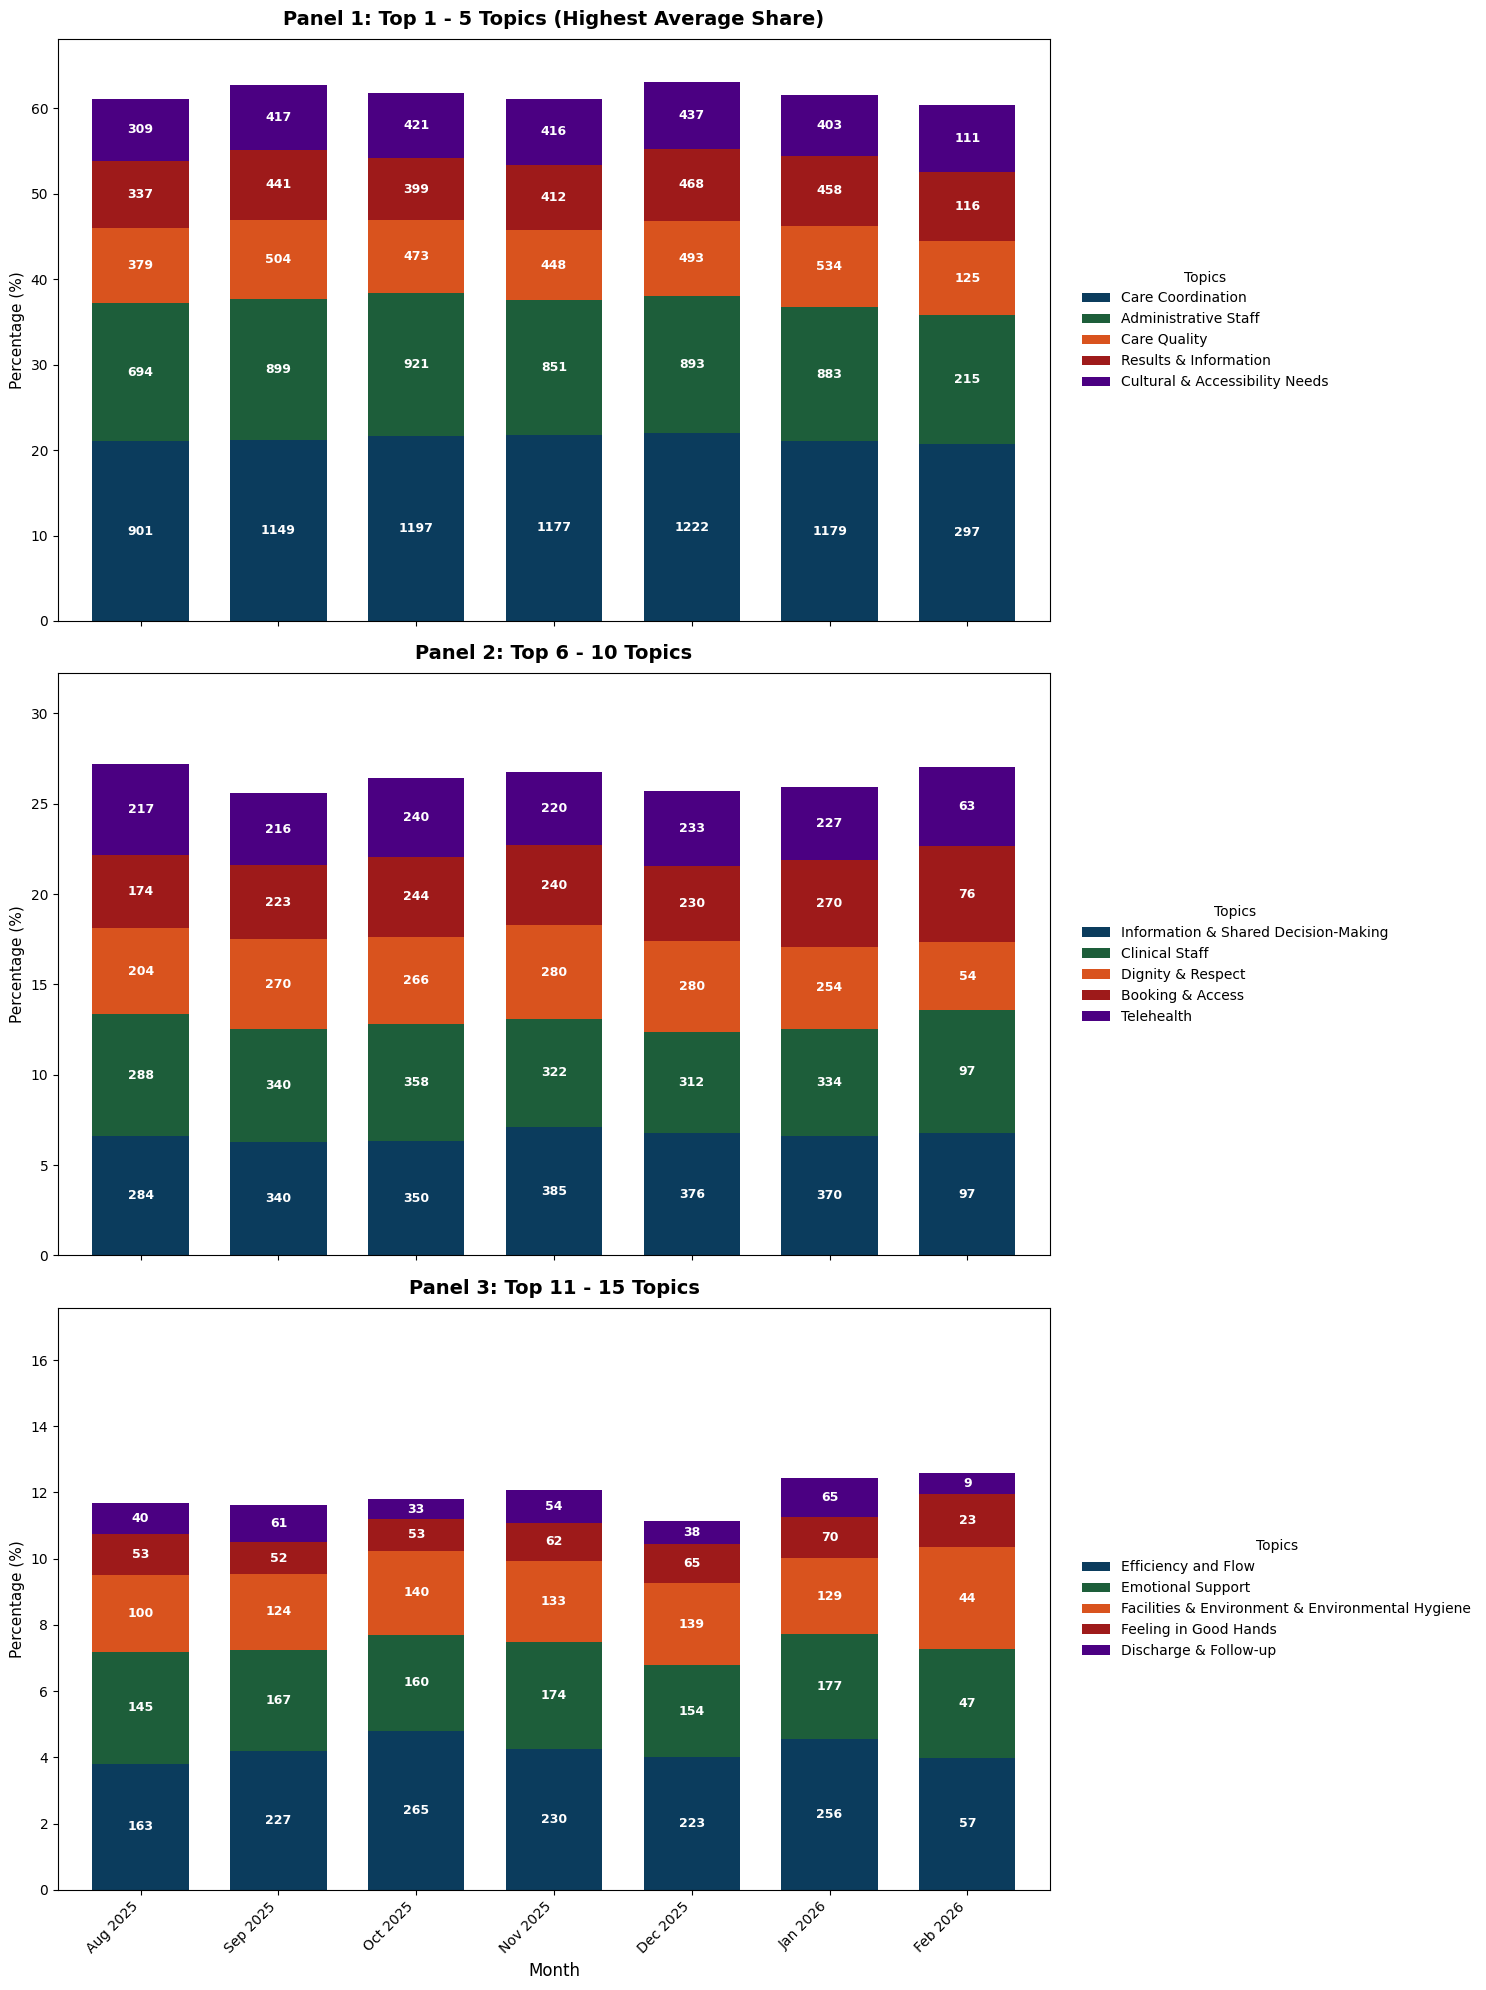

In [39]:
# Ensure Datetime is datetime type 
df_healthcare_triple['datetime'] = pd.to_datetime(df_healthcare_triple['datetime'])

# Group by month and topic, count tweets
monthly_topic_counts = df_healthcare_triple.groupby([df_healthcare_triple['datetime'].dt.to_period('M'), 'assigned_topic']).size().unstack(fill_value=0)

# Calculate percentage distribution per month
monthly_topic_percent = monthly_topic_counts.div(monthly_topic_counts.sum(axis=1), axis=0) * 100

# Sort topics by average percentage across all months (descending)
mean_topic_percent = monthly_topic_percent.mean().sort_values(ascending=False)

# Create two parallel DataFrames: one for percentage (heights) and one for counts (labels)
monthly_topic_percent_sorted = monthly_topic_percent[mean_topic_percent.index]
monthly_topic_counts_sorted = monthly_topic_counts[mean_topic_percent.index]

# Convert PeriodIndex to Timestamp for plotting
monthly_topic_percent_sorted.index = monthly_topic_percent_sorted.index.to_timestamp()
monthly_topic_counts_sorted.index = monthly_topic_counts_sorted.index.to_timestamp()

# --- 1. GENERATE THE 5 SHARED COLORS ---
colors_5 = [
    '#0B3C5D',  # Dark Blue (Deep Ocean)
    '#1D5E3A',  # Dark Green (Forest Slate)
    '#D9531E',  # Dark Orange (Burnt Amber)
    '#9E1A1A',  # Dark Red (Crimson Wine)
    '#4B0082'   # Dark Purple (Midnight Indigo)
]

# --- 2. SETUP THE 3 SUB-PANELS ---
fig, axes = plt.subplots(3, 1, figsize=(15, 20), sharex=True)

panel_titles = [
    'Panel 1: Top 1 - 5 Topics (Highest Average Share)',
    'Panel 2: Top 6 - 10 Topics',
    'Panel 3: Top 11 - 15 Topics'
]

# --- 3. LOOP AND PLOT EACH PANEL WITH LABELS ---
for i in range(3):
    start_col = i * 5
    end_col = (i + 1) * 5
    
    # Slice the percentage data (controls bar heights) and count data (controls text labels)
    panel_data_pct = monthly_topic_percent_sorted.iloc[:, start_col:end_col]
    panel_data_cnt = monthly_topic_counts_sorted.iloc[:, start_col:end_col]
    
    ax = axes[i]
    
    # Plot percentage stacked bars
    panel_data_pct.plot(
        kind='bar', 
        stacked=True, 
        color=colors_5, 
        width=0.7, 
        ax=ax
    )
    
    # --- ADD COUNT LABELS TO SEGMENTS ---
    # Loop through each column (topic) container plotted on the axis
    for c_idx, container in enumerate(ax.containers):
        # Extract the absolute counts for this specific topic across all months
        counts_array = panel_data_cnt.iloc[:, c_idx].values
        
        # Format counts as strings, hiding labels (using empty string) if count is 0 to avoid clutter
        labels = [f"{int(val)}" if val > 0 else "" for val in counts_array]
        
        # Inject labels into the center of each bar segment
        ax.bar_label(
            container, 
            labels=labels, 
            label_type='center', 
            fontsize=9, 
            color='white',       # White text works best against the vibrant Turbo colors
            fontweight='bold'
        )
    
    # Labeling and Styling
    ax.set_title(panel_titles[i], fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Percentage (%)', fontsize=11)
    ax.set_ylim(0, panel_data_pct.sum(axis=1).max() + 5) # Dynamically pads the top of each panel
    
    ax.legend(
        title='Topics', 
        loc='center left', 
        bbox_to_anchor=(1.02, 0.5), 
        frameon=False,
        fontsize=10
    )

# --- 4. FORMAT THE SHARED X-AXIS TIMESTAMPS ---
last_ax = axes[-1]
last_ax.set_xlabel('Month', fontsize=12)
last_ax.set_xticks(range(len(monthly_topic_percent_sorted.index)))
last_ax.set_xticklabels(
    [d.strftime('%b %Y') for d in monthly_topic_percent_sorted.index], 
    rotation=45, 
    ha='right'
)

plt.tight_layout()
plt.savefig('monthly_topic_distribution_with_counts.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
# 1. Create a raw frequency/count table of sentiments per topic
# (Change 'sentiment_label_clean' to 'sentiment_label' if needed)
counts_table = pd.crosstab(
    df_healthcare_triple["assigned_topic"],
    df_healthcare_triple["sentiment_label_clean"],
)

# 2. Convert the raw counts into percentages per row (Topic)
# .sum(axis=1) calculates the total reviews per topic, and axis=0 divides horizontally
topic_sentiment_proportion = counts_table.div(counts_table.sum(axis=1), axis=0) * 100

# 3. (Optional but Recommended) Ensure columns follow your exact logical order
desired_order = ["very positive", "positive", "negative", "very negative"]

# Filter desired order to only include columns that actually exist in your dataset
existing_order = [col for col in desired_order if col in topic_sentiment_proportion.columns]
topic_sentiment_proportion = topic_sentiment_proportion.reindex(columns=existing_order)

# Inspect the resulting table
print(topic_sentiment_proportion.head(15))

sentiment_label_clean                             very positive   positive  \
assigned_topic                                                               
Administrative Staff                                  24.365198  25.392084   
Booking & Access                                      19.835278  30.610844   
Care Coordination                                     23.687167  33.993260   
Care Quality                                          49.086604  23.037889   
Clinical Staff                                        25.938567  33.398342   
Cultural & Accessibility Needs                        35.163087  33.373111   
Dignity & Respect                                     33.706468  30.161692   
Discharge & Follow-up                                 37.000000  27.000000   
Efficiency and Flow                                   47.149894  19.985925   
Emotional Support                                     18.164062  35.351562   
Facilities & Environment & Environmental Hygiene      10.877627 

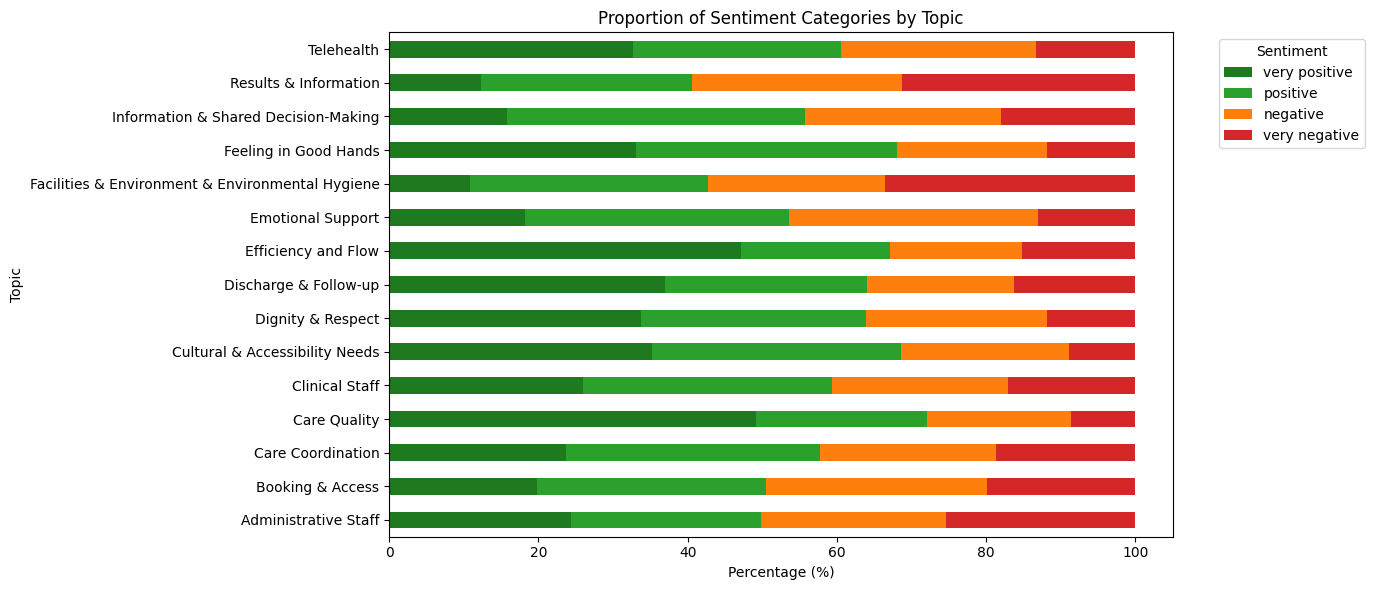

In [41]:
color_map = {
    'very positive': '#1F7A1F',  # dark green
    'positive': '#2CA02C',       # light green
    'negative': '#FF7F0E',       # light red
    'very negative': '#D62728'   # dark red
}

# Reindex the columns in the desired order
topic_sentiment_proportion = topic_sentiment_proportion.reindex(columns=desired_order)

# 1. Changed kind to 'barh' for horizontal bars
ax = topic_sentiment_proportion.plot(
    kind='barh', 
    stacked=True, 
    figsize=(14, 6), 
    width=0.5, # Controls the thickness of horizontal bars
    color=[color_map.get(x, '#333333') for x in topic_sentiment_proportion.columns]
)

plt.title("Proportion of Sentiment Categories by Topic")

# 2. Swapped Axis Labels for Horizontal Layout
plt.xlabel("Percentage (%)")
plt.ylabel("Topic")

# 3. Changed ylim to xlim to provide headroom on the right edge
plt.xlim(0, 105) 

# Legend remains cleanly pinned to the outside right edge
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Optional: Save image to your Kaggle outputs
plt.savefig('sentiment_by_topic_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# 1. Create a raw frequency/count table of sentiments per topic
# (Change 'sentiment_label_clean' to 'sentiment_label' if needed)
counts_table2 = pd.crosstab(
    df_healthcare_triple["assigned_topic"],
    df_healthcare_triple["label_clean"],
)

# 2. Convert the raw counts into percentages per row (Topic)
# .sum(axis=1) calculates the total reviews per topic, and axis=0 divides horizontally
topic_sentiment_proportion2 = counts_table2.div(counts_table2.sum(axis=1), axis=0) * 100

# 3. (Optional but Recommended) Ensure columns follow your exact logical order
desired_order2 = ["positive", "neutral", "negative"]

# Filter desired order to only include columns that actually exist in your dataset
existing_order2 = [col for col in desired_order2 if col in topic_sentiment_proportion2.columns]
topic_sentiment_proportion2 = topic_sentiment_proportion2.reindex(columns=existing_order2)

# Inspect the resulting table
print(topic_sentiment_proportion2.head(15))

label_clean                                        positive    neutral  \
assigned_topic                                                           
Administrative Staff                              32.879014  32.561613   
Booking & Access                                  45.024022  26.561428   
Care Coordination                                 50.042123  30.146026   
Care Quality                                      21.109608  61.197564   
Clinical Staff                                    57.142857  23.013164   
Cultural & Accessibility Needs                    58.194113  28.798727   
Dignity & Respect                                 57.960199  23.818408   
Discharge & Follow-up                             25.333333  56.000000   
Efficiency and Flow                               23.715693  61.224490   
Emotional Support                                 51.855469  26.269531   
Facilities & Environment & Environmental Hygiene  42.398022  21.384425   
Feeling in Good Hands                 

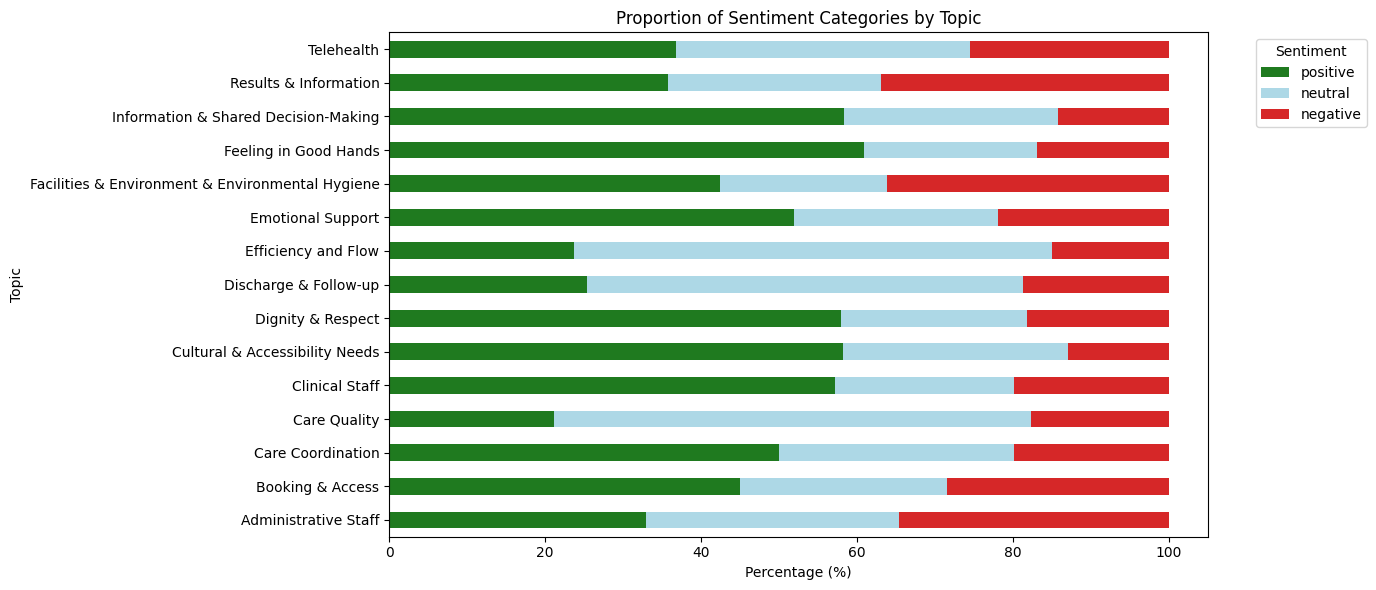

In [43]:
color_map2 = {
    'positive': '#1F7A1F',  # dark green
    'neutral': '#ADD8E6', # blue
    'negative': '#D62728'   # dark red
}

# Reindex the columns in the desired order
topic_sentiment_proportion2 = topic_sentiment_proportion2.reindex(columns=desired_order2)

# 1. Changed kind to 'barh' for horizontal bars
ax = topic_sentiment_proportion2.plot(
    kind='barh', 
    stacked=True, 
    figsize=(14, 6), 
    width=0.5, # Controls the thickness of horizontal bars
    color=[color_map2.get(x, '#333333') for x in topic_sentiment_proportion2.columns]
)

plt.title("Proportion of Sentiment Categories by Topic")

# 2. Swapped Axis Labels for Horizontal Layout
plt.xlabel("Percentage (%)")
plt.ylabel("Topic")

# 3. Changed ylim to xlim to provide headroom on the right edge
plt.xlim(0, 105) 

# Legend remains cleanly pinned to the outside right edge
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Optional: Save image to your Kaggle outputs
plt.savefig('sentiment_by_topic_horizontal2.png', dpi=300, bbox_inches='tight')
plt.show()

# 🌍 Geospatial and Temporal Analysis

we analyze the **spatial and temporal patterns** of patient reported experience-related sentiments and topics across different continents. Geospatial analysis involves mapping sentiment risk levels and topic distributions by **country** to identify hotspots or regions facing greater healthcare deficiency challenges. Temporal analysis tracks how these risk levels and thematic discussions evolve **over time**, such as monthly trends, allowing us to observe seasonal effects, emerging issues, or shifts in public concern.

This horizontal bar chart displays the distribution of tweets by risk level (🔴 High, 🟠 Medium, 🟢 Low) across different locations.

This visualization gives a clear picture of how risk perception and sentiment vary geographically 🌐.

In [44]:
# 1. Fill missing locations and merge
df_healthcare_triple["location"] = (
    df_healthcare_triple["Hospital"] + ", " + df_healthcare_triple["Country"]
)
df_healthcare_triple["location"] = df_healthcare_triple["location"].fillna(
    "Unknown"
)

# 2. Count the number of tweets per location and grab the top 100
location_counts = (
    df_healthcare_triple["location"].value_counts().reset_index(name="count")
)
location_counts.columns = ["location", "count"]
top_locations = location_counts.head(100)["location"]  # Fetches top 100

# 3. Filter data, excluding 'Unknown'
top_data = df_healthcare_triple[
    (df_healthcare_triple["location"].isin(top_locations))
    & (df_healthcare_triple["location"] != "Unknown")
]

# 4. Group by location and risk
risk_counts = (
    top_data.groupby(["location", "risk_label"]).size().reset_index(name="count")
)

# 5. Get sorted order of locations by total tweet count
location_order = (
    risk_counts.groupby("location")["count"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# Set color palette
risk_palette = {"Low": "green", "Medium": "orange", "High": "red"}

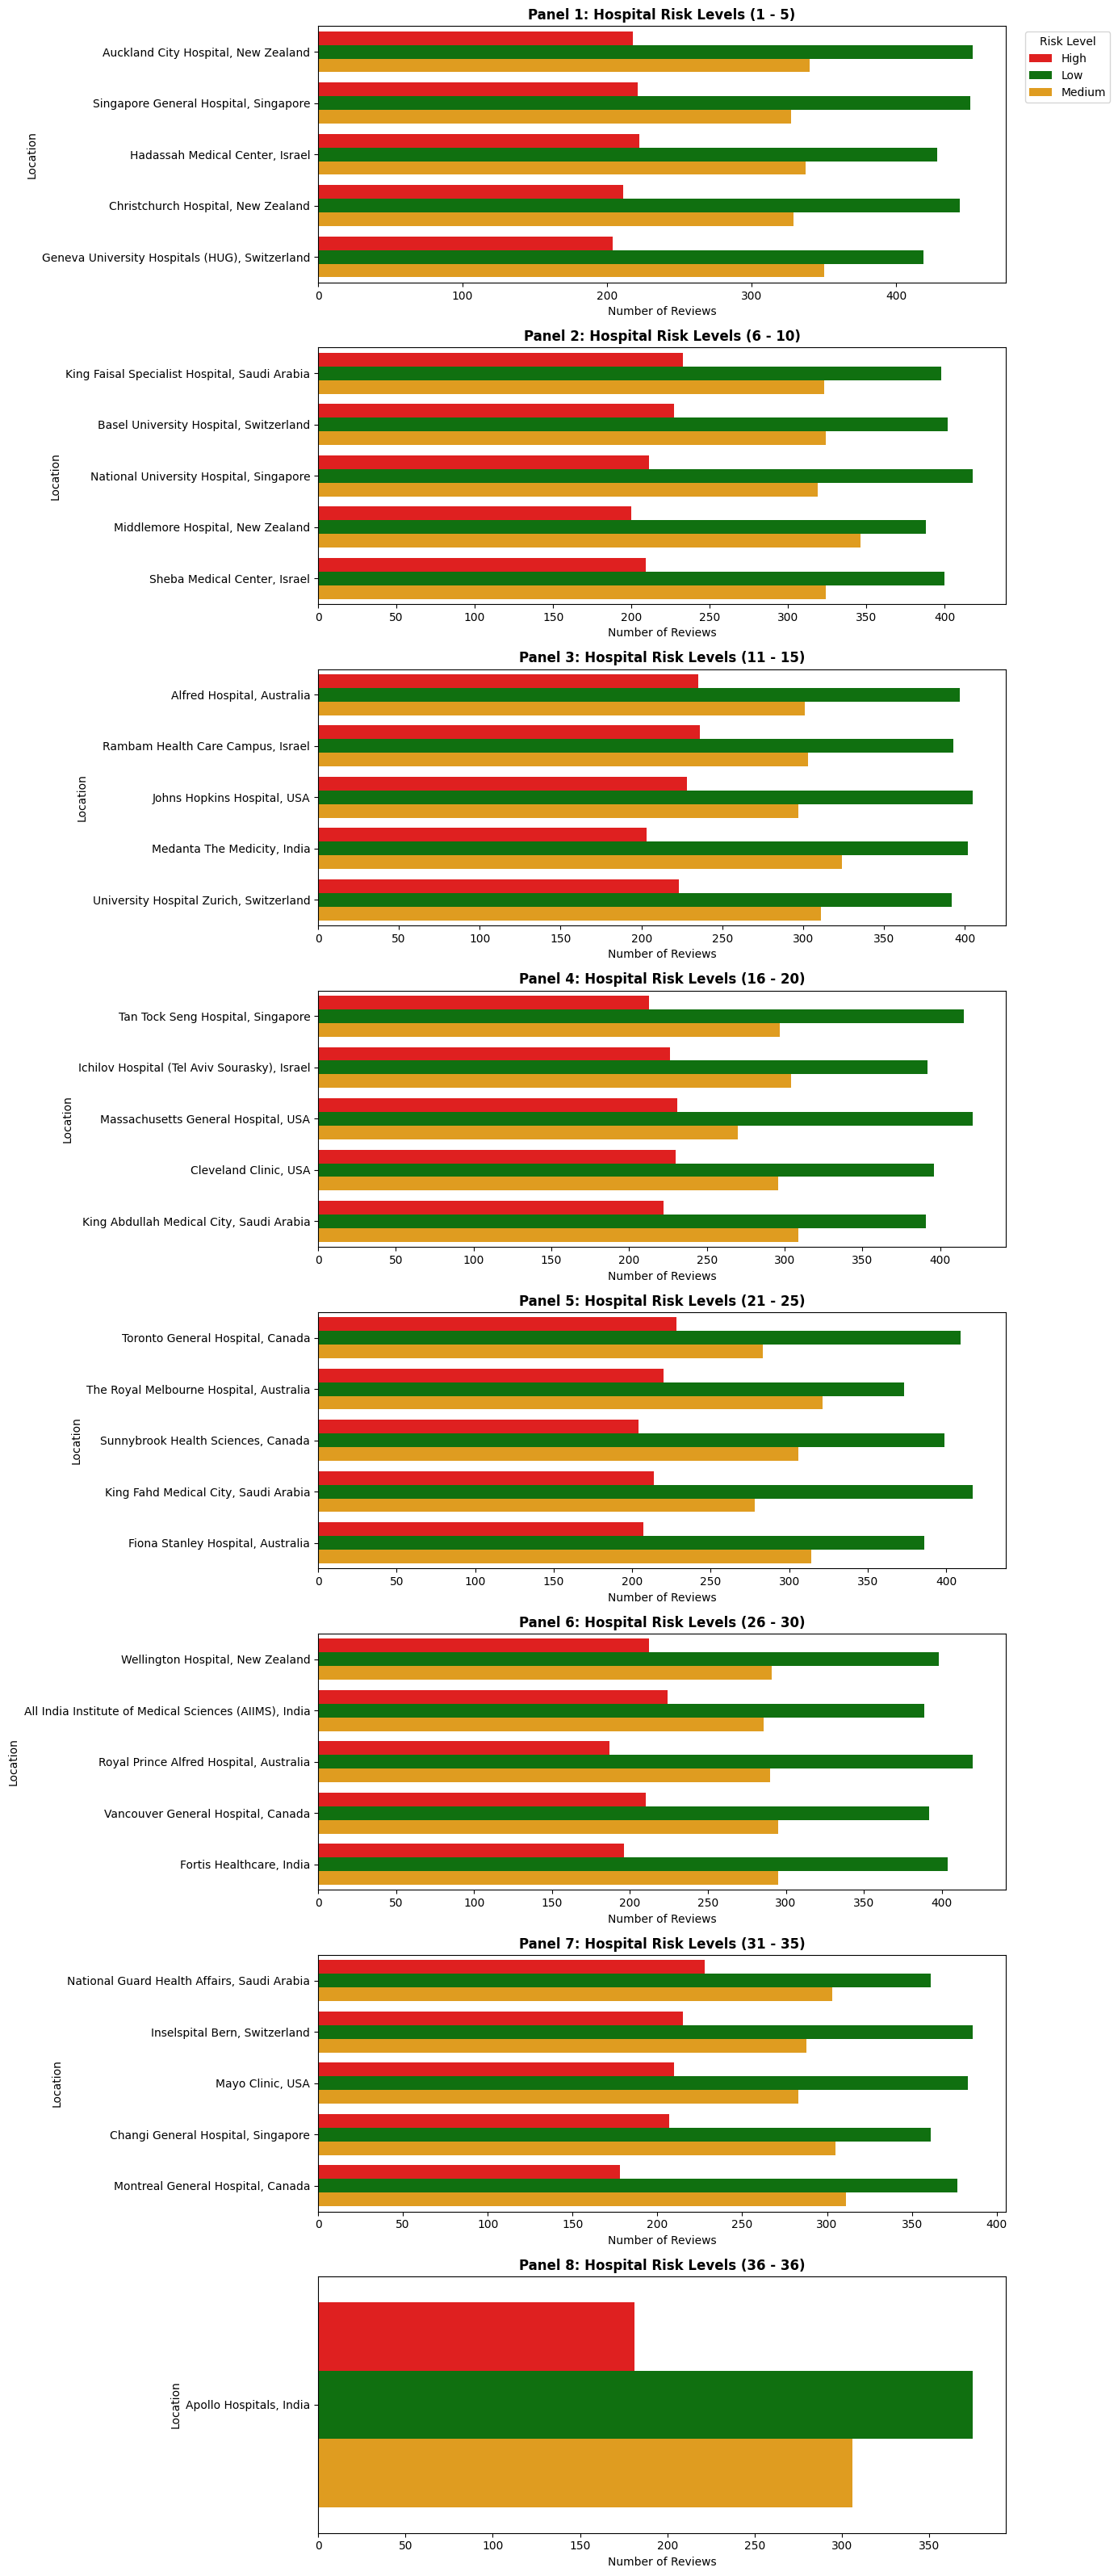

In [45]:
# --- NEW: SUB-PANEL SPLITTING LOGIC ---
hospitals_per_panel = 5
total_hospitals = len(location_order)
num_panels = math.ceil(total_hospitals / hospitals_per_panel)

# Setup a figure with vertical subplots
fig, axes = plt.subplots(
    num_panels, 1, figsize=(14, 4 * num_panels), sharex=False
)

# If there's only 1 panel, wrap it in a list so it remains iterable
if num_panels == 1:
    axes = [axes]

# Loop through each panel and plot 5 hospitals
for i in range(num_panels):
    start_idx = i * hospitals_per_panel
    end_idx = start_idx + hospitals_per_panel

    # Slice out the exact 5 hospitals for this specific panel
    panel_locations = location_order[start_idx:end_idx]

    # Filter our plotting data down to just these 5 locations
    panel_data = risk_counts[risk_counts["location"].isin(panel_locations)]

    ax = axes[i]

    # Plot onto the specific subplot axis
    sns.barplot(
        data=panel_data,
        y="location",
        x="count",
        hue="risk_label",
        palette=risk_palette,
        order=panel_locations,  # Maintains the overall sorted order within the chunk
        ax=ax,
    )

    # Formatting each sub-panel
    ax.set_title(
        f"Panel {i+1}: Hospital Risk Levels ({start_idx+1} - {min(end_idx, total_hospitals)})",
        fontsize=12,
        fontweight="bold",
    )
    ax.set_ylabel("Location", fontsize=10)
    ax.set_xlabel("Number of Reviews", fontsize=10)

    # --- UPDATED LEGEND POSITIONING ---
    if i == 0:
        # bbox_to_anchor=(1.02, 1) pushes the box to the right edge of the chart area
        ax.legend(
            title="Risk Level", 
            loc="upper left", 
            bbox_to_anchor=(1.02, 1), 
            frameon=True
        )
    else:
        ax.legend().remove()  # Only show the exterior legend on the first panel

plt.tight_layout()
plt.savefig(
    "hospital_risk_distribution_panels.png", dpi=300, bbox_inches="tight"
)
plt.show()

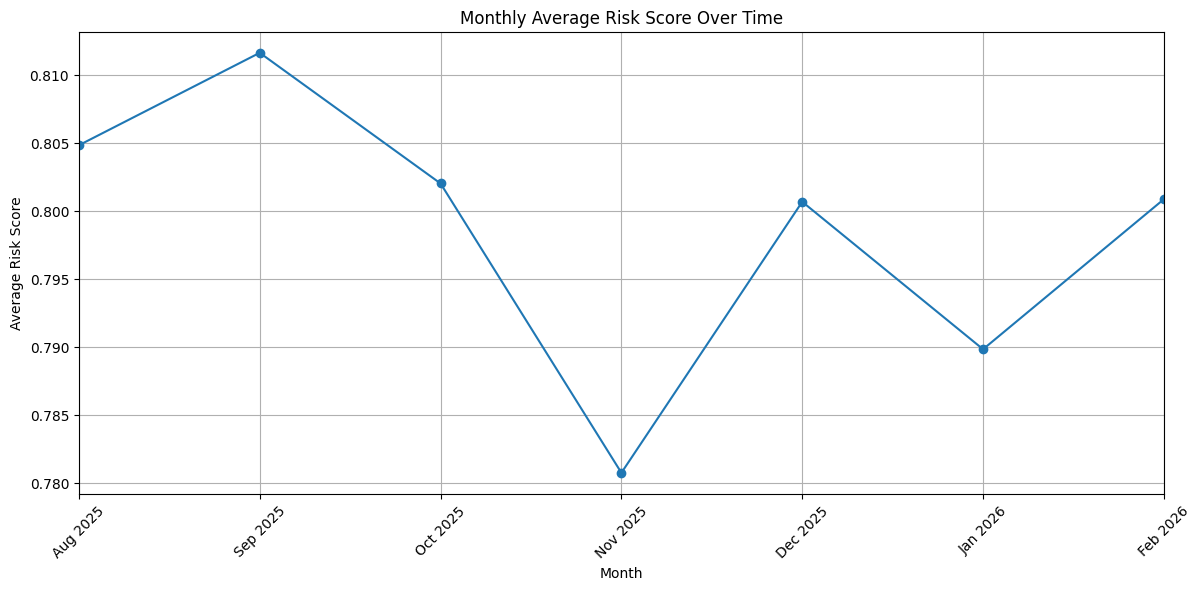

In [46]:
# Map risk levels to numeric scores temporarily for averaging
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_healthcare_triple['risk_score'] = df_healthcare_triple['risk_label'].map(risk_mapping)

# Make sure datetime column is in datetime format
df_healthcare_triple['datetime'] = pd.to_datetime(df_healthcare_triple['datetime']).dt.tz_localize(None)

monthly_risk = df_healthcare_triple.groupby(df_healthcare_triple['datetime'].dt.to_period('M'))['risk_score'].mean()

# Create full month range from min to max date in dataset
full_month_range = pd.period_range(start=df_healthcare_triple['datetime'].min().to_period('M'),
                                  end=df_healthcare_triple['datetime'].max().to_period('M'),
                                  freq='M')

# Reindex to full range, missing months will have NaN
monthly_risk = monthly_risk.reindex(full_month_range)


# Plot
plt.figure(figsize=(14, 6))
monthly_risk.index = monthly_risk.index.to_timestamp()  # Convert PeriodIndex to Timestamp for plotting
monthly_risk.plot(marker='o')
plt.title('Monthly Average Risk Score Over Time')
plt.xlabel('Month')
plt.ylabel('Average Risk Score')
plt.grid(True)

# Customize x-axis to show all months, formatted nicely
plt.xticks(monthly_risk.index, monthly_risk.index.strftime('%b %Y'), rotation=45)

plt.show()

# 💾 Save the Preprocessed Data and Pipeline

In [47]:
df_healthcare_triple.head(10)

,cleaned_review_text,label,datetime,label_encoded,text_length,translated_cleaned_review_text,Hospital,Country,recleaned_review_text,sentiment_score,sentiment_label,label_clean,sentiment_label_clean,risk_label,assigned_topic,location,risk_score
0,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,Neutral,2025-08-08 00:21:01,1,76,I see a lot of bad comments about this birth control and have no idea why. This is because I have been on this pill for 2 years and I love it. It made my boobs a whole cup size bigger and I did not gain any weight. I have also noticed I have no more mood swings and barely have a period. It is very good and I recommend it - also it is cheap.,King Faisal Specialist Hospital,Saudi Arabia,see lot bad comment birth control idea pill year love made boob whole cup size bigger gain weight also noticed mood swing barely period good recommend also cheap,0.1232,positive,neutral,positive,Medium,Administrative Staff,"King Faisal Specialist Hospital, Saudi Arabia",1
1,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Positive,2025-08-08 00:29:16,2,31,I had taken this before and lost 20 pounds due to a surgery I stopped and today I started at 253lb I'm hoping to go down to 180 wish me luck,Christchurch Hospital,New Zealand,taken lost pound due surgery stopped today started hoping go wish luck,0.6486,positive,positive,positive,Low,Cultural & Accessibility Needs,"Christchurch Hospital, New Zealand",0
2,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Neutral,2025-08-08 00:34:46,1,66,"This book started off slowly and I patiently waited for it to get better. But the more I read, the more bored I got and I realized that I didn't care about anything that was happening in the novel. The writing was dull as well as the characters. Gene causing Finny to break his leg and all the stuff that happened after was less than thrilling.",Sunnybrook Health Sciences,Canada,book started slowly patiently waited get better read bored got realized care anything happening novel writing dull well character gene causing finny break leg stuff happened less thrilling,0.0518,positive,neutral,positive,Medium,Care Quality,"Sunnybrook Health Sciences, Canada",1
3,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have a small dried blood scab the size of o. On day 2 of recovery the site of the insert is still tender but nothing you can notice unless you touch it. I still have the Nuvaring in and will take it out next Wednesday as the doctor advised. We will see how everything after that goes!,Neutral,2025-08-08 00:37:32,1,135,So I just got the Implanon on Wednesday and it is now Friday afternoon and I am happy with the healing process so far. The insertion is quick and I only freaked out because I really don't like BIG needles. The local anesthetic was a quick pinch and was quickly followed by the insertion of Implanon. The anesthetic is really only good for the day you get it and becomes sore by the next morning. Right now I have 

In [48]:
# Save to CSV
df_healthcare_triple.to_csv('prems_topic_ana_processed_data.csv', index=False)

In [49]:
# Save the pipeline to a file
joblib.dump(pipeline, 'prems_topic_ana_text_preprocessor_pipeline.joblib')

['prems_topic_ana_text_preprocessor_pipeline.joblib']

In [51]:
loaded_pipeline = joblib.load('/kaggle/working/prems_topic_ana_text_preprocessor_pipeline.joblib')

In [52]:
text = "The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age."

In [53]:
cleaned_text = loaded_pipeline.transform(text)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [54]:
cleaned_text

'parking albert street limited walk westfield car park difficult age'

# 🔗 E2E Topic Modeling Pipeline

In [55]:
# 1. Build an end-to-end Topic Modeling Pipeline
full_topic_pipeline = Pipeline([
    ('preprocessor', TextPreprocessor()),      # Custom cleaning step
    ('vectorizer', CountVectorizer()),         # Converts strings to numeric token matrices
    ('lda', LatentDirichletAllocation(n_components=n_topics,
                                      max_iter=20,
                                      learning_method='batch',
                                      random_state=0)) # LDA topic model
])

new_inputs = [
    "Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.",
    "I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month.",
    "The physiotherapist Michael was great. He gave me a detailed home exercise program after my knee surgery and followed up via email at susan.obrien82@gmail.com to check on my progress. Very impressed with that level of care.",
    "The online booking system could be easier to use. I ended up calling reception to book because I couldn't figure out the Zedoc portal. I was referred by Dr Nguyen at the Ipswich Hospital and the transition was smooth.",
    "Nurse Rebecca Taylor in the diabetes clinic was exceptional. She spent over 40 minutes with me going through my HbA1c results and adjusting my insulin plan. She also coordinated with my GP Dr Samantha Lee at the Toowoomba Medical Practice to ensure consistent care.",
    "I'm 81 years old and find the forms quite difficult to fill in. My daughter Sarah Fitzpatrick usually helps me but she wasn't available this time. Could you offer some assistance at the front desk for elderly patients? Also my Medicare number is 2345 67890 1 and I think there was a billing error on my last visit on 28 January 2026.",
    "Dr Patel is always thorough and patient. She remembers details from previous visits which makes me feel valued.",
    "The results portal is confusing. I had to call Dr Richardson's office at 07 3456 7891 to get my pathology explained because I couldn't understand the online report.",
    "The midwifery team, especially Lisa and Jenny, were amazing throughout my pregnancy. They made me feel safe and supported. The antenatal classes at the centre on George Street were also excellent.",
    "The parking at 45 Albert Street is very limited. I had to walk from the Westfield car park which is difficult at my age."
]

In [56]:
# 2. Fit the pipeline using raw, uncleaned text array 
# This trains both the vocabulary indexer and the topic components simultaneously
full_topic_pipeline.fit(new_inputs)

Pipeline(steps=[('preprocessor', TextPreprocessor()),
                ('vectorizer', CountVectorizer()),
                ('lda',
                 LatentDirichletAllocation(max_iter=20, n_components=15,
                                           random_state=0))])

In [57]:
# 3. Export the COMPLETE pipeline configuration securely using joblib
joblib.dump(full_topic_pipeline, 'full_topic_modeling_pipeline.joblib')
print("✅ Complete topic pipeline saved successfully!")

✅ Complete topic pipeline saved successfully!


In [59]:
# 1. Load the comprehensive pipeline
loaded_topic_pipeline = joblib.load('/kaggle/working/full_topic_modeling_pipeline.joblib')

# 3. Use .transform() to yield the raw distribution array (probability matrix)
# Shape will be: [number_of_samples, n_components]
topic_distributions = loaded_topic_pipeline.transform(new_inputs)

# 4. Use argmax to find the topic index with the highest probability value
best_topic_indices = np.argmax(topic_distributions, axis=1)

topic_names = {
    0: "Clinical Staff",
    1: "Administrative Staff",
    2: "Efficiency and Flow",
    3: "Booking & Access",
    4: "Information & Shared Decision-Making",
    5: "Dignity & Respect",
    6: "Care Quality",
    7: "Care Coordination",
    8: "Results & Information",
    9: "Facilities & Environment & Environmental Hygiene",
    10: "Telehealth",
    11: "Emotional Support",
    12: "Cultural & Accessibility Needs",
    13: "Discharge & Follow-up",
    14: "Feeling in Good Hands"
}

# 5. Loop and print mapped labels
for text, topic_idx in zip(new_inputs, best_topic_indices):
    human_readable_label = topic_names.get(topic_idx, "Unknown Topic")
    print(f"Input Text: {text}")
    print(f"Predicted Topic Index: {topic_idx} -> Label: {human_readable_label}")
    print("-" * 60)

Input Text: Dr Priya Patel in the respiratory clinic was absolutely wonderful. She took time to explain my COPD management plan and made sure I understood every step. The nurse on reception, Karen Thompson, was also very welcoming.
Predicted Topic Index: 6 -> Label: Care Quality
------------------------------------------------------------
Input Text: I had my appointment on 15 January 2026 at 2pm and wasn't seen until after 3:15pm. Dr James Richardson seemed rushed and didn't listen to my concerns about the medication side effects. I called the clinic at 07 3456 7890 twice before my appointment to ask about preparation and nobody answered. My wife Angela Chen had a much better experience at the Chermside Day Surgery last month.
Predicted Topic Index: 6 -> Label: Care Quality
------------------------------------------------------------
Input Text: The physiotherapist Michael was great. He gave me a detailed home exercise program after my knee surgery and followed up via email at susan.o